# Multi-Model zh↔vi — Notebook báo cáo (Bi-Mamba / Hybrid / Transformer)

Notebook **độc lập**, **chạy được end-to-end** trên Colab (Run All) cho bất kỳ
trong 3 model dùng chung tokenizer + data + training loop:

| `MODEL_KIND`   | Module                                | Config                                  | Run dir                          |
|----------------|---------------------------------------|-----------------------------------------|----------------------------------|
| `mamba`        | `BiMambaTranslator`                   | `configs/bi_mamba_55m.yaml`             | `runs/bi_mamba_55m/`             |
| `hybrid`       | `HybridMambaAttentionTranslator`      | `configs/hybrid_mamba_attention.yaml`   | `runs/hybrid_mamba_attention/`   |
| `transformer`  | `TransformerTranslator`               | `configs/transformer_30m.yaml`          | `runs/transformer_30m/`          |

Đặt `MODEL_KIND` ở **Mục 3** (cell config). Các phần phụ thuộc model (param breakdown,
BLEU/chrF, qualitative) đều chạy cho model đang chọn. **Mục 14** ở cuối tự động đánh
giá cả 3 model và xuất biểu đồ + CSV so sánh — chỉ cần checkpoint của mỗi model
nằm sẵn trong `runs/<run_dir>/` (sẽ tự skip model nào chưa có).

Tất cả figure → `reports/<MODEL_KIND>/figures/*.png`, các bảng → `reports/<MODEL_KIND>/*.csv`.
File so sánh 3 model → `reports/multi_model/`.

## 1. Mount Drive (tuỳ chọn) + clone repo

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as e:
    print('Skipping drive mount:', e)


Mounted at /content/drive


In [2]:
import os
REPO_URL = 'https://github.com/ChauDucToan/NLP_DHM.git'
REPO_DIR = '/home/oslamelon/Downloads/AI_NLP/NLP_DHM'

%cd $REPO_DIR
!pwd && ls


/home/oslamelon/Downloads/AI_NLP/NLP_DHM
/home/oslamelon/Downloads/AI_NLP/NLP_DHM
configs  LICENSE    pyproject.toml  reports	      runs     src    uv.lock
data	 notebooks  README.md	    requirements.txt  scripts  tests


## 2. Cài đặt dependencies

In [3]:
import sys; sys.path.insert(0, 'src')
import torch
print('torch:', torch.__version__,
      '| CUDA:', torch.cuda.is_available(),
      '| device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu')


torch: 2.11.0+cu130 | CUDA: True | device: NVIDIA GeForce RTX 5070 Ti


## 2b. System info (cho reproducibility)

Ghi lại torch / CUDA / GPU / cuDNN của runtime hiện tại để paper / thesis có thể trích.

In [4]:
import sys, platform, torch, json
from pathlib import Path

info = {
    "python":         sys.version.split()[0],
    "platform":       platform.platform(),
    "torch":          torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version":   torch.version.cuda if torch.cuda.is_available() else None,
    "cudnn_version":  (torch.backends.cudnn.version() if torch.cuda.is_available() else None),
    "gpu":            (torch.cuda.get_device_name(0) if torch.cuda.is_available() else None),
    "gpu_capability": (".".join(map(str, torch.cuda.get_device_capability(0))) if torch.cuda.is_available() else None),
}
for k, v in info.items():
    print(f"{k:18s} {v}")

Path("reports").mkdir(exist_ok=True)
Path("reports/system_info.json").write_text(json.dumps(info, indent=2))
print("\nSaved reports/system_info.json")

python             3.12.13
platform           Linux-6.19.13-xanmod1-x86_64-with-glibc2.42
torch              2.11.0+cu130
cuda_available     True
cuda_version       13.0
cudnn_version      91900
gpu                NVIDIA GeForce RTX 5070 Ti
gpu_capability     12.0

Saved reports/system_info.json


## 3. Cấu hình MODEL_KIND + đường dẫn

Đổi `MODEL_KIND` ở cell dưới để chuyển notebook sang model khác. Tất cả các cell
sau sẽ tuân theo lựa chọn này. Mục 14 vẫn tự động chạy cả 3 model độc lập với
giá trị `MODEL_KIND` ở đây.

In [5]:
from pathlib import Path
import yaml

# === Pick one ===
MODEL_KIND = 'mamba'   # 'mamba' | 'hybrid' | 'transformer'

_REGISTRY = {
    'mamba': dict(
        config_path  = 'configs/bi_mamba_55m.yaml',
        run_dir      = 'runs/bi_mamba_55m',
        eval_script  = 'scripts/evaluate.py',
        train_script = 'scripts/train.py',
        drive_dir    = 'runs/bi_mamba_55m',
    ),
    'hybrid': dict(
        config_path  = 'configs/hybrid_mamba_attention.yaml',
        run_dir      = 'runs/hybrid_mamba_attention',
        eval_script  = 'scripts/evaluate_hybrid.py',
        train_script = 'scripts/train_hybrid.py',
        drive_dir    = 'runs/hybrid_mamba_attention',
    ),
    'transformer': dict(
        config_path  = 'configs/transformer_30m.yaml',
        run_dir      = 'runs/transformer_30m',
        eval_script  = 'scripts/evaluate_transformer.py',
        train_script = 'scripts/train_transformer.py',
        drive_dir    = 'runs/transformer_30m',
    ),
}
assert MODEL_KIND in _REGISTRY, f'Unknown MODEL_KIND: {MODEL_KIND}'
META = dict(_REGISTRY[MODEL_KIND])

# Per-model output dirs.
REPORT_DIR = Path('reports') / MODEL_KIND
FIG_DIR    = REPORT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Allow user to override config to a Colab-specific config (e.g. fp16 instead of bf16).
CONFIG_PATH = (Path('configs/_colab.yaml') if Path('configs/_colab.yaml').exists()
               else Path(META['config_path']))
RUN_DIR     = Path(META['run_dir'])
TOKEN_DIR   = Path('runs/tokenizer')
TRAIN_LOG   = REPORT_DIR / 'training_stdout.log'
TRAIN_LOG.parent.mkdir(parents=True, exist_ok=True)

# Prefer Drive copy if available.
DRIVE_RUN_DIR = Path(META['drive_dir'])
if DRIVE_RUN_DIR.exists():
    print(f'Using Drive run dir: {DRIVE_RUN_DIR}')
    RUN_DIR = DRIVE_RUN_DIR
    if (DRIVE_RUN_DIR / 'tokenizer' / 'spm.model').exists():
        TOKEN_DIR = DRIVE_RUN_DIR / 'tokenizer'
    drive_log = DRIVE_RUN_DIR / 'training_stdout.log'
    if drive_log.exists():
        TRAIN_LOG = drive_log
        print(f'Using Drive log: {TRAIN_LOG}')

CFG_PREVIEW = yaml.safe_load(open(CONFIG_PATH))
FULL_EVAL_N = int(CFG_PREVIEW.get('eval', {}).get('num_samples', 5000))
DEFAULT_EVAL_BEAM = int(CFG_PREVIEW.get('eval', {}).get('beam_size', 4))
DEFAULT_MAX_DECODE_LEN = int(CFG_PREVIEW.get('eval', {}).get('max_decode_len', 256))
_lp_cfg = CFG_PREVIEW.get('eval', {}).get('length_penalty', 1.0)
if isinstance(_lp_cfg, dict):
    REPORT_LENGTH_PENALTY = {
        'zh2vi': float(_lp_cfg.get('zh2vi', 1.0)),
        'vi2zh': float(_lp_cfg.get('vi2zh', 1.0)),
    }
else:
    REPORT_LENGTH_PENALTY = {'zh2vi': float(_lp_cfg), 'vi2zh': float(_lp_cfg)}

# Report controls. Change only this variable in normal use.
REPORT_PRESET = 'draft'   # 'draft' | 'final'

_REPORT_PRESETS = {
    'draft': {
        'num_samples': 300,
        'sample_seed': 42,
        'beam': 1,
        'max_decode_len': None,
        'run_sweep': False,
    },
    'final': {
        'num_samples': FULL_EVAL_N,
        'sample_seed': 42,
        'beam': 2,
        'max_decode_len': None,
        'run_sweep': False,
    },
}
if REPORT_PRESET not in _REPORT_PRESETS:
    raise ValueError(f'Unknown REPORT_PRESET: {REPORT_PRESET}')

_REPORT_CFG = dict(_REPORT_PRESETS[REPORT_PRESET])
REPORT_NUM_SAMPLES = int(_REPORT_CFG['num_samples'])
REPORT_SAMPLE_SEED = _REPORT_CFG['sample_seed']
REPORT_BEAM = _REPORT_CFG['beam']
REPORT_MAX_DECODE_LEN = _REPORT_CFG['max_decode_len']
RUN_SWEEP = bool(_REPORT_CFG['run_sweep'])

REPORT_BEAM_EFFECTIVE = DEFAULT_EVAL_BEAM if REPORT_BEAM is None else int(REPORT_BEAM)
REPORT_MAX_DECODE_LEN_EFFECTIVE = (
    DEFAULT_MAX_DECODE_LEN if REPORT_MAX_DECODE_LEN is None else int(REPORT_MAX_DECODE_LEN)
)
REPORT_IS_DRAFT = REPORT_PRESET == 'draft'
REPORT_LABEL = 'DRAFT METRICS' if REPORT_IS_DRAFT else 'FINAL METRICS'
REPORT_SLUG = REPORT_PRESET

# Sweep controls.
SWEEP_N = REPORT_NUM_SAMPLES
SWEEP_SAMPLE_SEED = REPORT_SAMPLE_SEED

# Balanced qualitative examples: short / medium / long / names / numbers / dialogue.
QUAL_ZH2VI = [
    "你好，世界。",
    "今天天气真好。",
    "王小明已经在河内住了三年。",
    "会议将于2025年6月12日上午9点开始，请提前十分钟到场。",
    "服务员说：'这道菜有点辣，如果你不能吃辣，我可以帮你换一份。'",
    "虽然模型在短句上表现不错，但一遇到包含数字、专有名词和转折结构的长句，错误就会明显增多。",
]
QUAL_VI2ZH = [
    'Hôm nay trời rất đẹp.',
    'Xin chào, tôi là Lan.',
    'Anh Nguyễn Minh đã làm việc ở TP. Hồ Chí Minh từ năm 2021.',
    'Cuộc họp sẽ bắt đầu lúc 9 giờ sáng ngày 12 tháng 6 năm 2025, vui lòng đến sớm 10 phút.',
    "Người phục vụ nói: 'Món này hơi cay, nếu bạn không ăn cay được thì tôi đổi món khác cho bạn.'",
    'Mặc dù mô hình dịch khá ổn với câu ngắn, nó thường mắc nhiều lỗi hơn khi gặp câu dài có số liệu, tên riêng và cấu trúc tương phản.',
]

print(f'MODEL_KIND  = {MODEL_KIND}')
print(f'CONFIG      = {CONFIG_PATH}')
print(f'RUN_DIR     = {RUN_DIR}')
print(f'TOKEN_DIR   = {TOKEN_DIR}')
print(f'TRAIN_LOG   = {TRAIN_LOG}  (exists={TRAIN_LOG.exists()})')
print(f'REPORT_DIR  = {REPORT_DIR}')
print(f'FIG_DIR     = {FIG_DIR}')
print(f'REPORT      = {REPORT_LABEL} | n={REPORT_NUM_SAMPLES} | seed={REPORT_SAMPLE_SEED} | beam={REPORT_BEAM_EFFECTIVE} | max_len={REPORT_MAX_DECODE_LEN_EFFECTIVE}')
print(f'LP          = zh2vi={REPORT_LENGTH_PENALTY["zh2vi"]:.2f}, vi2zh={REPORT_LENGTH_PENALTY["vi2zh"]:.2f}')
print(f'RUN_SWEEP   = {RUN_SWEEP} | sweep_n={SWEEP_N} | sweep_seed={SWEEP_SAMPLE_SEED}')
print()
print('Files in run dir:')
if RUN_DIR.exists():
    for p in sorted(RUN_DIR.glob('*'))[:30]:
        print(' ', p.name)
else:
    print('  (does not exist yet — train first or copy from Drive)')


Using Drive run dir: runs/bi_mamba_55m
MODEL_KIND  = mamba
CONFIG      = configs/bi_mamba_55m.yaml
RUN_DIR     = runs/bi_mamba_55m
TOKEN_DIR   = runs/tokenizer
TRAIN_LOG   = reports/mamba/training_stdout.log  (exists=False)
REPORT_DIR  = reports/mamba
FIG_DIR     = reports/mamba/figures
REPORT      = DRAFT METRICS | n=300 | seed=42 | beam=1 | max_len=256
LP          = zh2vi=1.00, vi2zh=0.90
RUN_SWEEP   = False | sweep_n=300 | sweep_seed=42

Files in run dir:
  config.yaml
  final.pt
  latest.pt


## 3b. Tự động chuẩn bị dữ liệu + tokenizer (chạy 1 lần, có cache)

Nếu `data/processed/train.jsonl` hoặc `data/tokenizer/spm.model` chưa có, ô
này sẽ tự gọi `scripts/prepare_data.py` (tải OPUS theo `data.preset` của
config, lọc + cap + split) rồi `scripts/train_tokenizer.py` (huấn luyện
SentencePiece BPE). Chạy lại lần sau sẽ skip vì file đã có sẵn.

Mặc định preset là `everyday` (~225K cặp sạch, ~700 MB download một lần
do NLLB). Bạn có thể đổi sang `tiny` (~50K cặp, ~1 MB) nếu chỉ muốn
smoke-test nhanh, hoặc `small` (~200K cặp, ~25 MB) để bỏ NLLB +
OpenSubtitles cho lần chạy đầu nhẹ hơn.


In [6]:
import subprocess, sys, yaml
from pathlib import Path

cfg_dict = yaml.safe_load(open(CONFIG_PATH))
data_cfg = cfg_dict['data']
DATA_PROC = Path(data_cfg.get('processed_dir', 'data/processed'))
DATA_RAW  = Path(data_cfg.get('raw_dir',       'data/raw'))
DATA_TOK  = Path(data_cfg.get('tokenizer_dir', 'data/tokenizer'))
DATA_PROC.mkdir(parents=True, exist_ok=True)

def _run(cmd):
    print('  $', ' '.join(cmd))
    p = subprocess.run(cmd, capture_output=True, text=True)
    print(p.stdout[-2500:] if len(p.stdout) > 2500 else p.stdout, end='')
    if p.returncode != 0:
        print('STDERR:', p.stderr[-1500:])
        raise SystemExit(f'command failed: {cmd}')

# Step 1: download + clean + split
need_prep = not (DATA_PROC / 'train.jsonl').exists()
if need_prep:
    print('=== prepare_data.py ===')
    _run(['uv', 'run', 'python', 'scripts/prepare_data.py',
          '--config', str(CONFIG_PATH),
          '--preset', str(data_cfg.get('preset', 'everyday'))])
else:
    print(f'cache hit: {DATA_PROC/"train.jsonl"} ({(DATA_PROC/"train.jsonl").stat().st_size/1e6:.1f} MB)')

# Step 2: train SentencePiece BPE tokenizer
spm_path = DATA_TOK / 'spm.model'
if not spm_path.exists():
    print('\n=== train_tokenizer.py ===')
    _run(['uv', 'run', 'python', 'scripts/train_tokenizer.py', '--config', str(CONFIG_PATH)])
else:
    print(f'cache hit: {spm_path} ({spm_path.stat().st_size/1e3:.0f} KB)')

# Update TOKEN_DIR if we just trained one and Drive doesn't override.
if not (TOKEN_DIR / 'spm.model').exists() and (DATA_TOK / 'spm.model').exists():
    TOKEN_DIR = DATA_TOK
print(f'\nTOKEN_DIR (final) = {TOKEN_DIR}')


cache hit: data/processed/train.jsonl (29.5 MB)
cache hit: data/tokenizer/spm.model (462 KB)

TOKEN_DIR (final) = runs/tokenizer


## 4. Cung cấp stdout của ô Train

Có **2 cách** để có file `TRAIN_LOG`:

**Cách A — paste trực tiếp vào ô bên dưới** (nhanh, không cần Drive).
Mở notebook gốc → click chuột phải vào output của ô Train → *Copy output* →
dán vào ô bên dưới (giữa 2 dấu `'''`).

**Cách B — đọc từ file `.log`** (đã `wget`/`copy` lên Colab hoặc Drive).
Bỏ qua cell A, đảm bảo `TRAIN_LOG` ở cell trên trỏ đúng tới file.

In [7]:
PASTED_STDOUT_HYBRID = '''
Train pairs: 125279 | Valid pairs: 5000
Using length-bucketed sampler (pool=100*batch=128)
Model parameters: 32.79M (32,792,256)
  -> new best val_loss 6.6749 @ step 1000 (saved best.pt)
  -> new best ema_val_loss 7.8778 @ step 1000 (saved best_ema.pt)
step 1000 | val_loss 6.675 (best 6.675) | ema_val_loss 7.878 (best 7.878)
  -> new best val_loss 5.6872 @ step 2000 (saved best.pt)
  -> new best ema_val_loss 6.5041 @ step 2000 (saved best_ema.pt)
step 2000 | val_loss 5.687 (best 5.687) | ema_val_loss 6.504 (best 6.504)
  -> new best val_loss 4.8650 @ step 3000 (saved best.pt)
  -> new best ema_val_loss 5.4969 @ step 3000 (saved best_ema.pt)
step 3000 | val_loss 4.865 (best 4.865) | ema_val_loss 5.497 (best 5.497)
  -> new best val_loss 4.1745 @ step 4000 (saved best.pt)
  -> new best ema_val_loss 4.6793 @ step 4000 (saved best_ema.pt)
step 4000 | val_loss 4.175 (best 4.175) | ema_val_loss 4.679 (best 4.679)
  -> new best val_loss 3.8136 @ step 5000 (saved best.pt)
  -> new best ema_val_loss 4.0592 @ step 5000 (saved best_ema.pt)
step 5000 | val_loss 3.814 (best 3.814) | ema_val_loss 4.059 (best 4.059)
  -> new best val_loss 3.5720 @ step 6000 (saved best.pt)
  -> new best ema_val_loss 3.6692 @ step 6000 (saved best_ema.pt)
step 6000 | val_loss 3.572 (best 3.572) | ema_val_loss 3.669 (best 3.669)
  -> new best val_loss 3.4848 @ step 7000 (saved best.pt)
  -> new best ema_val_loss 3.4394 @ step 7000 (saved best_ema.pt)
step 7000 | val_loss 3.485 (best 3.485) | ema_val_loss 3.439 (best 3.439)
  -> new best val_loss 3.3918 @ step 8000 (saved best.pt)
  -> new best ema_val_loss 3.2943 @ step 8000 (saved best_ema.pt)
step 8000 | val_loss 3.392 (best 3.392) | ema_val_loss 3.294 (best 3.294)
  -> new best val_loss 3.2970 @ step 9000 (saved best.pt)
  -> new best ema_val_loss 3.1964 @ step 9000 (saved best_ema.pt)
step 9000 | val_loss 3.297 (best 3.297) | ema_val_loss 3.196 (best 3.196)
  -> new best val_loss 3.2454 @ step 10000 (saved best.pt)
  -> new best ema_val_loss 3.1249 @ step 10000 (saved best_ema.pt)
step 10000 | val_loss 3.245 (best 3.245) | ema_val_loss 3.125 (best 3.125)
  -> new best val_loss 3.2402 @ step 11000 (saved best.pt)
  -> new best ema_val_loss 3.0643 @ step 11000 (saved best_ema.pt)
step 11000 | val_loss 3.240 (best 3.240) | ema_val_loss 3.064 (best 3.064)
  -> new best val_loss 3.1609 @ step 12000 (saved best.pt)
  -> new best ema_val_loss 3.0167 @ step 12000 (saved best_ema.pt)
step 12000 | val_loss 3.161 (best 3.161) | ema_val_loss 3.017 (best 3.017)
  -> new best val_loss 3.1252 @ step 13000 (saved best.pt)
  -> new best ema_val_loss 2.9864 @ step 13000 (saved best_ema.pt)
step 13000 | val_loss 3.125 (best 3.125) | ema_val_loss 2.986 (best 2.986)
  -> new best val_loss 3.0906 @ step 14000 (saved best.pt)
  -> new best ema_val_loss 2.9512 @ step 14000 (saved best_ema.pt)
step 14000 | val_loss 3.091 (best 3.091) | ema_val_loss 2.951 (best 2.951)
  -> new best val_loss 3.0765 @ step 15000 (saved best.pt)
  -> new best ema_val_loss 2.9306 @ step 15000 (saved best_ema.pt)
step 15000 | val_loss 3.076 (best 3.076) | ema_val_loss 2.931 (best 2.931)
  -> new best val_loss 3.0447 @ step 16000 (saved best.pt)
  -> new best ema_val_loss 2.9029 @ step 16000 (saved best_ema.pt)
step 16000 | val_loss 3.045 (best 3.045) | ema_val_loss 2.903 (best 2.903)
  -> new best val_loss 2.9930 @ step 17000 (saved best.pt)
  -> new best ema_val_loss 2.8889 @ step 17000 (saved best_ema.pt)
step 17000 | val_loss 2.993 (best 2.993) | ema_val_loss 2.889 (best 2.889)
  -> new best val_loss 2.9769 @ step 18000 (saved best.pt)
  -> new best ema_val_loss 2.8728 @ step 18000 (saved best_ema.pt)
step 18000 | val_loss 2.977 (best 2.977) | ema_val_loss 2.873 (best 2.873)
  -> new best val_loss 2.9744 @ step 19000 (saved best.pt)
  -> new best ema_val_loss 2.8659 @ step 19000 (saved best_ema.pt)
step 19000 | val_loss 2.974 (best 2.974) | ema_val_loss 2.866 (best 2.866)
  -> new best val_loss 2.9576 @ step 20000 (saved best.pt)
  -> new best ema_val_loss 2.8532 @ step 20000 (saved best_ema.pt)
step 20000 | val_loss 2.958 (best 2.958) | ema_val_loss 2.853 (best 2.853)
  -> new best ema_val_loss 2.8479 @ step 21000 (saved best_ema.pt)
step 21000 | val_loss 2.983 (best 2.958) | ema_val_loss 2.848 (best 2.848)
  -> new best ema_val_loss 2.8400 @ step 22000 (saved best_ema.pt)
step 22000 | val_loss 2.962 (best 2.958) | ema_val_loss 2.840 (best 2.840)
  -> new best val_loss 2.9199 @ step 23000 (saved best.pt)
  -> new best ema_val_loss 2.8328 @ step 23000 (saved best_ema.pt)
step 23000 | val_loss 2.920 (best 2.920) | ema_val_loss 2.833 (best 2.833)
  -> new best val_loss 2.9135 @ step 24000 (saved best.pt)
  -> new best ema_val_loss 2.8220 @ step 24000 (saved best_ema.pt)
step 24000 | val_loss 2.913 (best 2.913) | ema_val_loss 2.822 (best 2.822)
  -> new best val_loss 2.9026 @ step 25000 (saved best.pt)
step 25000 | val_loss 2.903 (best 2.903) | ema_val_loss 2.823 (best 2.822)
  early-stop: no improvement on ema_val_loss for 1/10 eval(s) (best 2.8220)
  -> new best ema_val_loss 2.8182 @ step 26000 (saved best_ema.pt)
step 26000 | val_loss 2.934 (best 2.903) | ema_val_loss 2.818 (best 2.818)
step 27000 | val_loss 2.911 (best 2.903) | ema_val_loss 2.822 (best 2.818)
  early-stop: no improvement on ema_val_loss for 1/10 eval(s) (best 2.8182)
  -> new best ema_val_loss 2.8175 @ step 28000 (saved best_ema.pt)
step 28000 | val_loss 2.931 (best 2.903) | ema_val_loss 2.818 (best 2.818)
  -> new best val_loss 2.8770 @ step 29000 (saved best.pt)
  -> new best ema_val_loss 2.8130 @ step 29000 (saved best_ema.pt)
step 29000 | val_loss 2.877 (best 2.877) | ema_val_loss 2.813 (best 2.813)
step 30000 | val_loss 2.894 (best 2.877) | ema_val_loss 2.817 (best 2.813)
  early-stop: no improvement on ema_val_loss for 1/10 eval(s) (best 2.8130)
step 31000 | val_loss 2.892 (best 2.877) | ema_val_loss 2.815 (best 2.813)
  early-stop: no improvement on ema_val_loss for 2/10 eval(s) (best 2.8130)
step 32000 | val_loss 2.917 (best 2.877) | ema_val_loss 2.820 (best 2.813)
  early-stop: no improvement on ema_val_loss for 3/10 eval(s) (best 2.8130)
  -> new best val_loss 2.8632 @ step 33000 (saved best.pt)
step 33000 | val_loss 2.863 (best 2.863) | ema_val_loss 2.817 (best 2.813)
  early-stop: no improvement on ema_val_loss for 4/10 eval(s) (best 2.8130)
step 34000 | val_loss 2.893 (best 2.863) | ema_val_loss 2.822 (best 2.813)
  early-stop: no improvement on ema_val_loss for 5/10 eval(s) (best 2.8130)
step 35000 | val_loss 2.884 (best 2.863) | ema_val_loss 2.820 (best 2.813)
  early-stop: no improvement on ema_val_loss for 6/10 eval(s) (best 2.8130)
step 36000 | val_loss 2.899 (best 2.863) | ema_val_loss 2.829 (best 2.813)
  early-stop: no improvement on ema_val_loss for 7/10 eval(s) (best 2.8130)
step 37000 | val_loss 2.873 (best 2.863) | ema_val_loss 2.826 (best 2.813)
  early-stop: no improvement on ema_val_loss for 8/10 eval(s) (best 2.8130)
step 38000 | val_loss 2.896 (best 2.863) | ema_val_loss 2.835 (best 2.813)
  early-stop: no improvement on ema_val_loss for 9/10 eval(s) (best 2.8130)
step 39000 | val_loss 2.880 (best 2.863) | ema_val_loss 2.831 (best 2.813)
  early-stop: no improvement on ema_val_loss for 10/10 eval(s) (best 2.8130)
  early-stop: triggered at step 39000 (no ema_val_loss improvement for 10 evals). Stopping.
train:  65% 39000/60000 [1:57:50<1:03:27,  5.52it/s, loss=2.968, lr=1.3e-04]
Saved final model: runs/hybrid_mamba_attention/final.pt
'''.strip()

In [8]:
PASTED_STDOUT_TRANSFORMER = '''
Train pairs: 125279 | Valid pairs: 5000
Using length-bucketed sampler (pool=100*batch=128)
/content/NLP_DHM/src/transformer_mt/model.py:93: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(
Model parameters: 30.79M (30,788,096)
  -> new best val_loss 6.5839 @ step 1000 (saved best.pt)
  -> new best ema_val_loss 7.8033 @ step 1000 (saved best_ema.pt)
step 1000 | val_loss 6.584 (best 6.584) | ema_val_loss 7.803 (best 7.803)
  -> new best val_loss 5.6024 @ step 2000 (saved best.pt)
  -> new best ema_val_loss 6.4233 @ step 2000 (saved best_ema.pt)
step 2000 | val_loss 5.602 (best 5.602) | ema_val_loss 6.423 (best 6.423)
  -> new best val_loss 4.9007 @ step 3000 (saved best.pt)
  -> new best ema_val_loss 5.4478 @ step 3000 (saved best_ema.pt)
step 3000 | val_loss 4.901 (best 4.901) | ema_val_loss 5.448 (best 5.448)
  -> new best val_loss 4.3806 @ step 4000 (saved best.pt)
  -> new best ema_val_loss 4.7342 @ step 4000 (saved best_ema.pt)
step 4000 | val_loss 4.381 (best 4.381) | ema_val_loss 4.734 (best 4.734)
  -> new best val_loss 3.9612 @ step 5000 (saved best.pt)
  -> new best ema_val_loss 4.2021 @ step 5000 (saved best_ema.pt)
step 5000 | val_loss 3.961 (best 3.961) | ema_val_loss 4.202 (best 4.202)
  -> new best val_loss 3.6680 @ step 6000 (saved best.pt)
  -> new best ema_val_loss 3.7721 @ step 6000 (saved best_ema.pt)
step 6000 | val_loss 3.668 (best 3.668) | ema_val_loss 3.772 (best 3.772)
  -> new best val_loss 3.5097 @ step 7000 (saved best.pt)
  -> new best ema_val_loss 3.4897 @ step 7000 (saved best_ema.pt)
step 7000 | val_loss 3.510 (best 3.510) | ema_val_loss 3.490 (best 3.490)
  -> new best val_loss 3.3889 @ step 8000 (saved best.pt)
  -> new best ema_val_loss 3.3120 @ step 8000 (saved best_ema.pt)
step 8000 | val_loss 3.389 (best 3.389) | ema_val_loss 3.312 (best 3.312)
  -> new best val_loss 3.2846 @ step 9000 (saved best.pt)
  -> new best ema_val_loss 3.1979 @ step 9000 (saved best_ema.pt)
step 9000 | val_loss 3.285 (best 3.285) | ema_val_loss 3.198 (best 3.198)
  -> new best val_loss 3.2182 @ step 10000 (saved best.pt)
  -> new best ema_val_loss 3.1097 @ step 10000 (saved best_ema.pt)
step 10000 | val_loss 3.218 (best 3.218) | ema_val_loss 3.110 (best 3.110)
  -> new best val_loss 3.1522 @ step 11000 (saved best.pt)
  -> new best ema_val_loss 3.0463 @ step 11000 (saved best_ema.pt)
step 11000 | val_loss 3.152 (best 3.152) | ema_val_loss 3.046 (best 3.046)
  -> new best val_loss 3.1057 @ step 12000 (saved best.pt)
  -> new best ema_val_loss 2.9924 @ step 12000 (saved best_ema.pt)
step 12000 | val_loss 3.106 (best 3.106) | ema_val_loss 2.992 (best 2.992)
  -> new best val_loss 3.0688 @ step 13000 (saved best.pt)
  -> new best ema_val_loss 2.9563 @ step 13000 (saved best_ema.pt)
step 13000 | val_loss 3.069 (best 3.069) | ema_val_loss 2.956 (best 2.956)
  -> new best val_loss 3.0357 @ step 14000 (saved best.pt)
  -> new best ema_val_loss 2.9193 @ step 14000 (saved best_ema.pt)
step 14000 | val_loss 3.036 (best 3.036) | ema_val_loss 2.919 (best 2.919)
  -> new best val_loss 3.0183 @ step 15000 (saved best.pt)
  -> new best ema_val_loss 2.8925 @ step 15000 (saved best_ema.pt)
step 15000 | val_loss 3.018 (best 3.018) | ema_val_loss 2.892 (best 2.892)
  -> new best val_loss 2.9761 @ step 16000 (saved best.pt)
  -> new best ema_val_loss 2.8674 @ step 16000 (saved best_ema.pt)
step 16000 | val_loss 2.976 (best 2.976) | ema_val_loss 2.867 (best 2.867)
  -> new best val_loss 2.9672 @ step 17000 (saved best.pt)
  -> new best ema_val_loss 2.8491 @ step 17000 (saved best_ema.pt)
step 17000 | val_loss 2.967 (best 2.967) | ema_val_loss 2.849 (best 2.849)
  -> new best val_loss 2.9547 @ step 18000 (saved best.pt)
  -> new best ema_val_loss 2.8297 @ step 18000 (saved best_ema.pt)
step 18000 | val_loss 2.955 (best 2.955) | ema_val_loss 2.830 (best 2.830)
  -> new best val_loss 2.9165 @ step 19000 (saved best.pt)
  -> new best ema_val_loss 2.8158 @ step 19000 (saved best_ema.pt)
step 19000 | val_loss 2.917 (best 2.917) | ema_val_loss 2.816 (best 2.816)
  -> new best ema_val_loss 2.8011 @ step 20000 (saved best_ema.pt)
step 20000 | val_loss 2.922 (best 2.917) | ema_val_loss 2.801 (best 2.801)
  -> new best val_loss 2.9024 @ step 21000 (saved best.pt)
  -> new best ema_val_loss 2.7936 @ step 21000 (saved best_ema.pt)
step 21000 | val_loss 2.902 (best 2.902) | ema_val_loss 2.794 (best 2.794)
  -> new best val_loss 2.8962 @ step 22000 (saved best.pt)
  -> new best ema_val_loss 2.7849 @ step 22000 (saved best_ema.pt)
step 22000 | val_loss 2.896 (best 2.896) | ema_val_loss 2.785 (best 2.785)
  -> new best val_loss 2.8739 @ step 23000 (saved best.pt)
  -> new best ema_val_loss 2.7778 @ step 23000 (saved best_ema.pt)
step 23000 | val_loss 2.874 (best 2.874) | ema_val_loss 2.778 (best 2.778)
  -> new best ema_val_loss 2.7691 @ step 24000 (saved best_ema.pt)
step 24000 | val_loss 2.875 (best 2.874) | ema_val_loss 2.769 (best 2.769)
  -> new best val_loss 2.8484 @ step 25000 (saved best.pt)
  -> new best ema_val_loss 2.7640 @ step 25000 (saved best_ema.pt)
step 25000 | val_loss 2.848 (best 2.848) | ema_val_loss 2.764 (best 2.764)
  -> new best ema_val_loss 2.7576 @ step 26000 (saved best_ema.pt)
step 26000 | val_loss 2.850 (best 2.848) | ema_val_loss 2.758 (best 2.758)
  -> new best val_loss 2.8313 @ step 27000 (saved best.pt)
  -> new best ema_val_loss 2.7540 @ step 27000 (saved best_ema.pt)
step 27000 | val_loss 2.831 (best 2.831) | ema_val_loss 2.754 (best 2.754)
  -> new best ema_val_loss 2.7511 @ step 28000 (saved best_ema.pt)
step 28000 | val_loss 2.835 (best 2.831) | ema_val_loss 2.751 (best 2.751)
  -> new best val_loss 2.8200 @ step 29000 (saved best.pt)
  -> new best ema_val_loss 2.7480 @ step 29000 (saved best_ema.pt)
step 29000 | val_loss 2.820 (best 2.820) | ema_val_loss 2.748 (best 2.748)
  -> new best ema_val_loss 2.7457 @ step 30000 (saved best_ema.pt)
step 30000 | val_loss 2.822 (best 2.820) | ema_val_loss 2.746 (best 2.746)
  -> new best val_loss 2.8145 @ step 31000 (saved best.pt)
  -> new best ema_val_loss 2.7431 @ step 31000 (saved best_ema.pt)
step 31000 | val_loss 2.814 (best 2.814) | ema_val_loss 2.743 (best 2.743)
  -> new best val_loss 2.8107 @ step 32000 (saved best.pt)
step 32000 | val_loss 2.811 (best 2.811) | ema_val_loss 2.743 (best 2.743)
  early-stop: no improvement on ema_val_loss for 1/6 eval(s) (best 2.7431)
  -> new best val_loss 2.7861 @ step 33000 (saved best.pt)
  -> new best ema_val_loss 2.7401 @ step 33000 (saved best_ema.pt)
step 33000 | val_loss 2.786 (best 2.786) | ema_val_loss 2.740 (best 2.740)
step 34000 | val_loss 2.802 (best 2.786) | ema_val_loss 2.743 (best 2.740)
  early-stop: no improvement on ema_val_loss for 1/6 eval(s) (best 2.7401)
  -> new best val_loss 2.7850 @ step 35000 (saved best.pt)
  -> new best ema_val_loss 2.7387 @ step 35000 (saved best_ema.pt)
step 35000 | val_loss 2.785 (best 2.785) | ema_val_loss 2.739 (best 2.739)
step 36000 | val_loss 2.789 (best 2.785) | ema_val_loss 2.739 (best 2.739)
  early-stop: no improvement on ema_val_loss for 1/6 eval(s) (best 2.7387)
  -> new best val_loss 2.7821 @ step 37000 (saved best.pt)
  -> new best ema_val_loss 2.7387 @ step 37000 (saved best_ema.pt)
step 37000 | val_loss 2.782 (best 2.782) | ema_val_loss 2.739 (best 2.739)
step 38000 | val_loss 2.786 (best 2.782) | ema_val_loss 2.743 (best 2.739)
  early-stop: no improvement on ema_val_loss for 1/6 eval(s) (best 2.7387)
  -> new best val_loss 2.7729 @ step 39000 (saved best.pt)
step 39000 | val_loss 2.773 (best 2.773) | ema_val_loss 2.740 (best 2.739)
  early-stop: no improvement on ema_val_loss for 2/6 eval(s) (best 2.7387)
step 40000 | val_loss 2.783 (best 2.773) | ema_val_loss 2.745 (best 2.739)
  early-stop: no improvement on ema_val_loss for 3/6 eval(s) (best 2.7387)
  -> new best val_loss 2.7646 @ step 41000 (saved best.pt)
step 41000 | val_loss 2.765 (best 2.765) | ema_val_loss 2.742 (best 2.739)
  early-stop: no improvement on ema_val_loss for 4/6 eval(s) (best 2.7387)
step 42000 | val_loss 2.781 (best 2.765) | ema_val_loss 2.746 (best 2.739)
  early-stop: no improvement on ema_val_loss for 5/6 eval(s) (best 2.7387)
step 43000 | val_loss 2.766 (best 2.765) | ema_val_loss 2.745 (best 2.739)
  early-stop: no improvement on ema_val_loss for 6/6 eval(s) (best 2.7387)
  early-stop: triggered at step 43000 (no ema_val_loss improvement for 6 evals). Stopping.
train:  72% 43000/60000 [1:13:52<29:12,  9.70it/s, loss=2.713, lr=1.1e-04]
Saved final model: runs/transformer_30m/final.pt
'''.strip()

In [9]:
PASTED_STDOUT_MT5 = '''
Train pairs: 125279 | Valid pairs: 5000
Using length-bucketed sampler (pool=100*batch=128)
Model parameters: 32.43M (32,432,256)
  -> new best val_loss 6.4194 @ step 1000 (saved best.pt)
  -> new best ema_val_loss 7.7787 @ step 1000 (saved best_ema.pt)
step 1000 | val_loss 6.419 (best 6.419) | ema_val_loss 7.779 (best 7.779)
  -> new best val_loss 5.4581 @ step 2000 (saved best.pt)
  -> new best ema_val_loss 6.2306 @ step 2000 (saved best_ema.pt)
step 2000 | val_loss 5.458 (best 5.458) | ema_val_loss 6.231 (best 6.231)
  -> new best val_loss 4.6967 @ step 3000 (saved best.pt)
  -> new best ema_val_loss 5.2920 @ step 3000 (saved best_ema.pt)
step 3000 | val_loss 4.697 (best 4.697) | ema_val_loss 5.292 (best 5.292)
  -> new best val_loss 4.0643 @ step 4000 (saved best.pt)
  -> new best ema_val_loss 4.5457 @ step 4000 (saved best_ema.pt)
step 4000 | val_loss 4.064 (best 4.064) | ema_val_loss 4.546 (best 4.546)
  -> new best val_loss 3.7065 @ step 5000 (saved best.pt)
  -> new best ema_val_loss 3.9634 @ step 5000 (saved best_ema.pt)
step 5000 | val_loss 3.706 (best 3.706) | ema_val_loss 3.963 (best 3.963)
  -> new best val_loss 3.4696 @ step 6000 (saved best.pt)
  -> new best ema_val_loss 3.5801 @ step 6000 (saved best_ema.pt)
step 6000 | val_loss 3.470 (best 3.470) | ema_val_loss 3.580 (best 3.580)
  -> new best val_loss 3.3787 @ step 7000 (saved best.pt)
  -> new best ema_val_loss 3.3533 @ step 7000 (saved best_ema.pt)
step 7000 | val_loss 3.379 (best 3.379) | ema_val_loss 3.353 (best 3.353)
  -> new best val_loss 3.3132 @ step 8000 (saved best.pt)
  -> new best ema_val_loss 3.2131 @ step 8000 (saved best_ema.pt)
step 8000 | val_loss 3.313 (best 3.313) | ema_val_loss 3.213 (best 3.213)
  -> new best val_loss 3.2082 @ step 9000 (saved best.pt)
  -> new best ema_val_loss 3.1208 @ step 9000 (saved best_ema.pt)
step 9000 | val_loss 3.208 (best 3.208) | ema_val_loss 3.121 (best 3.121)
  -> new best val_loss 3.1743 @ step 10000 (saved best.pt)
  -> new best ema_val_loss 3.0526 @ step 10000 (saved best_ema.pt)
step 10000 | val_loss 3.174 (best 3.174) | ema_val_loss 3.053 (best 3.053)
  -> new best val_loss 3.1617 @ step 11000 (saved best.pt)
  -> new best ema_val_loss 2.9978 @ step 11000 (saved best_ema.pt)
step 11000 | val_loss 3.162 (best 3.162) | ema_val_loss 2.998 (best 2.998)
  -> new best val_loss 3.0745 @ step 12000 (saved best.pt)
  -> new best ema_val_loss 2.9527 @ step 12000 (saved best_ema.pt)
step 12000 | val_loss 3.075 (best 3.075) | ema_val_loss 2.953 (best 2.953)
  -> new best val_loss 3.0486 @ step 13000 (saved best.pt)
  -> new best ema_val_loss 2.9296 @ step 13000 (saved best_ema.pt)
step 13000 | val_loss 3.049 (best 3.049) | ema_val_loss 2.930 (best 2.930)
  -> new best val_loss 3.0355 @ step 14000 (saved best.pt)
  -> new best ema_val_loss 2.9000 @ step 14000 (saved best_ema.pt)
step 14000 | val_loss 3.036 (best 3.036) | ema_val_loss 2.900 (best 2.900)
  -> new best val_loss 3.0175 @ step 15000 (saved best.pt)
  -> new best ema_val_loss 2.8824 @ step 15000 (saved best_ema.pt)
step 15000 | val_loss 3.017 (best 3.017) | ema_val_loss 2.882 (best 2.882)
  -> new best val_loss 2.9866 @ step 16000 (saved best.pt)
  -> new best ema_val_loss 2.8571 @ step 16000 (saved best_ema.pt)
step 16000 | val_loss 2.987 (best 2.987) | ema_val_loss 2.857 (best 2.857)
  -> new best val_loss 2.9694 @ step 17000 (saved best.pt)
  -> new best ema_val_loss 2.8498 @ step 17000 (saved best_ema.pt)
step 17000 | val_loss 2.969 (best 2.969) | ema_val_loss 2.850 (best 2.850)
  -> new best val_loss 2.9410 @ step 18000 (saved best.pt)
  -> new best ema_val_loss 2.8379 @ step 18000 (saved best_ema.pt)
step 18000 | val_loss 2.941 (best 2.941) | ema_val_loss 2.838 (best 2.838)
  -> new best val_loss 2.9405 @ step 19000 (saved best.pt)
  -> new best ema_val_loss 2.8342 @ step 19000 (saved best_ema.pt)
step 19000 | val_loss 2.940 (best 2.940) | ema_val_loss 2.834 (best 2.834)
  -> new best val_loss 2.9256 @ step 20000 (saved best.pt)
  -> new best ema_val_loss 2.8249 @ step 20000 (saved best_ema.pt)
step 20000 | val_loss 2.926 (best 2.926) | ema_val_loss 2.825 (best 2.825)
step 21000 | val_loss 2.969 (best 2.926) | ema_val_loss 2.825 (best 2.825)
  early-stop: no improvement on ema_val_loss for 1/6 eval(s) (best 2.8249)
  -> new best ema_val_loss 2.8209 @ step 22000 (saved best_ema.pt)
step 22000 | val_loss 2.946 (best 2.926) | ema_val_loss 2.821 (best 2.821)
  -> new best val_loss 2.9074 @ step 23000 (saved best.pt)
  -> new best ema_val_loss 2.8186 @ step 23000 (saved best_ema.pt)
step 23000 | val_loss 2.907 (best 2.907) | ema_val_loss 2.819 (best 2.819)
  -> new best ema_val_loss 2.8147 @ step 24000 (saved best_ema.pt)
step 24000 | val_loss 2.909 (best 2.907) | ema_val_loss 2.815 (best 2.815)
  -> new best val_loss 2.9066 @ step 25000 (saved best.pt)
step 25000 | val_loss 2.907 (best 2.907) | ema_val_loss 2.819 (best 2.815)
  early-stop: no improvement on ema_val_loss for 1/6 eval(s) (best 2.8147)
step 26000 | val_loss 2.936 (best 2.907) | ema_val_loss 2.817 (best 2.815)
  early-stop: no improvement on ema_val_loss for 2/6 eval(s) (best 2.8147)
step 27000 | val_loss 2.915 (best 2.907) | ema_val_loss 2.828 (best 2.815)
  early-stop: no improvement on ema_val_loss for 3/6 eval(s) (best 2.8147)
step 28000 | val_loss 2.943 (best 2.907) | ema_val_loss 2.829 (best 2.815)
  early-stop: no improvement on ema_val_loss for 4/6 eval(s) (best 2.8147)
  -> new best val_loss 2.8779 @ step 29000 (saved best.pt)
step 29000 | val_loss 2.878 (best 2.878) | ema_val_loss 2.827 (best 2.815)
  early-stop: no improvement on ema_val_loss for 5/6 eval(s) (best 2.8147)
step 30000 | val_loss 2.925 (best 2.878) | ema_val_loss 2.835 (best 2.815)
  early-stop: no improvement on ema_val_loss for 6/6 eval(s) (best 2.8147)
  early-stop: triggered at step 30000 (no ema_val_loss improvement for 6 evals). Stopping.
train:  50% 30000/60000 [1:40:00<1:40:00,  5.00it/s, loss=2.831, lr=1.7e-04]
Saved final model: runs/bi_mamba_55m/final.pt
'''.strip()

In [10]:
# === D. Auto-load OR paste training log ===
# Cell 7 already prefers RUN_DIR/training_stdout.log nếu user train với
# `uv run python scripts/train_*.py ... | tee runs/<run_dir>/training_stdout.log`.
# Nếu file vẫn chưa tồn tại, paste stdout Train trực tiếp vào dưới (giữ nguyên
# để tương thích lại flow cũ).

PASTED_STDOUT_LIST = [
    ('bimamba', PASTED_STDOUT_MT5),
    ('transformer', PASTED_STDOUT_TRANSFORMER),
    ('hybrid', PASTED_STDOUT_HYBRID)
]
for STDOUT_NAME, PASTED_STDOUT in PASTED_STDOUT_LIST:
    if TRAIN_LOG.exists() and TRAIN_LOG.stat().st_size > 0:
        print(f'Auto-load OK: {TRAIN_LOG} ({TRAIN_LOG.stat().st_size/1024:.1f} KB) — '
              f'cell parse log sẽ dùng file này.')
    elif PASTED_STDOUT and 'step' in PASTED_STDOUT and 'val_loss' in PASTED_STDOUT:
        TRAIN_LOG_PATH = TRAIN_LOG.parent / f'training_stdout_{STDOUT_NAME}.log'
        TRAIN_LOG_PATH.write_text(PASTED_STDOUT)
        print(f'Wrote {len(PASTED_STDOUT):,} bytes to {TRAIN_LOG_PATH}')
    else:
        print(f'NOTE: Không có log ở {TRAIN_LOG}.\n'
              f'  - (Khuyến nghị) train với:  uv run python scripts/train_*.py ... | tee {RUN_DIR}/training_stdout.log\n'
              f'  - HOẶC paste stdout vào biến PASTED_STDOUT ở cell trên rồi chạy lại.')

Wrote 5,988 bytes to reports/mamba/training_stdout_bimamba.log
Wrote 8,592 bytes to reports/mamba/training_stdout_transformer.log
Wrote 7,448 bytes to reports/mamba/training_stdout_hybrid.log


## 5. Parse log → DataFrame

Trainer in ra 2 dạng dòng:
* `step N | val_loss V.VVV (best B.BBB) | ema_val_loss V.VVV (best B.BBB)` — khi EMA bật.
* `step N | val_loss V.VVV (best B.BBB)` — khi EMA tắt.

Regex bên dưới bắt cả 2 dạng.

In [11]:
import re
import pandas as pd

df_eval_list = []
# Soft-skip: nếu chưa có log, df_eval rỗng → các cell phụ thuộc tự bỏ qua.
for STDOUT_NAME, PASTED_STDOUT in PASTED_STDOUT_LIST:
    TRAIN_LOG_PATH = TRAIN_LOG.parent / f'training_stdout_{STDOUT_NAME}.log'

    HAVE_LOG = TRAIN_LOG_PATH.exists() and TRAIN_LOG_PATH.stat().st_size > 0
    if not HAVE_LOG:
        print(f'NOTE: Không có log ở {TRAIN_LOG_PATH} → các biểu đồ loss sẽ skip. '
              f'Quay lại mục 4 paste stdout nếu muốn vẽ loss curves.')

    PAT = re.compile(
        r'step\s+(\d+)\s+\|\s+val_loss\s+([\d.]+)\s+\(best\s+([\d.]+)\)'
        r'(?:\s+\|\s+ema_val_loss\s+([\d.]+)\s+\(best\s+([\d.]+)\))?'
    )

    rows = []
    if HAVE_LOG:
        for line in TRAIN_LOG_PATH.read_text(errors='replace').splitlines():
            m = PAT.search(line)
            if not m:
                continue
            d = {
                'step': int(m.group(1)),
                'val_loss': float(m.group(2)),
                'best_val_loss': float(m.group(3)),
            }
            if m.group(4):
                d['ema_val_loss']      = float(m.group(4))
                d['best_ema_val_loss'] = float(m.group(5))
            rows.append(d)

    df_eval = pd.DataFrame(rows)
    if len(df_eval):
        df_eval = df_eval.drop_duplicates(subset=['step']).sort_values('step').reset_index(drop=True)

    print(f'Parsed {len(df_eval)} eval points from log.')
    if len(df_eval):
        print(f'  Steps: {df_eval.step.min():,} → {df_eval.step.max():,}')
        print(f'  Best val_loss = {df_eval.best_val_loss.min():.4f} '
              f'@ step {int(df_eval.loc[df_eval.val_loss.idxmin(), "step"]):,}')
        if 'best_ema_val_loss' in df_eval:
            print(f'  Best ema_val_loss = {df_eval.best_ema_val_loss.min():.4f} '
                  f'@ step {int(df_eval.loc[df_eval.ema_val_loss.idxmin(), "step"]):,}')
    df_eval.tail() if len(df_eval) else df_eval
    df_eval_list.append((STDOUT_NAME, df_eval))


Parsed 30 eval points from log.
  Steps: 1,000 → 30,000
  Best val_loss = 2.8780 @ step 29,000
  Best ema_val_loss = 2.8150 @ step 24,000
Parsed 43 eval points from log.
  Steps: 1,000 → 43,000
  Best val_loss = 2.7650 @ step 41,000
  Best ema_val_loss = 2.7390 @ step 35,000
Parsed 39 eval points from log.
  Steps: 1,000 → 39,000
  Best val_loss = 2.8630 @ step 33,000
  Best ema_val_loss = 2.8130 @ step 29,000


## 6. Loss curves (val + EMA-val)

Saved: reports/mamba/figures/loss_curves_bimamba.png


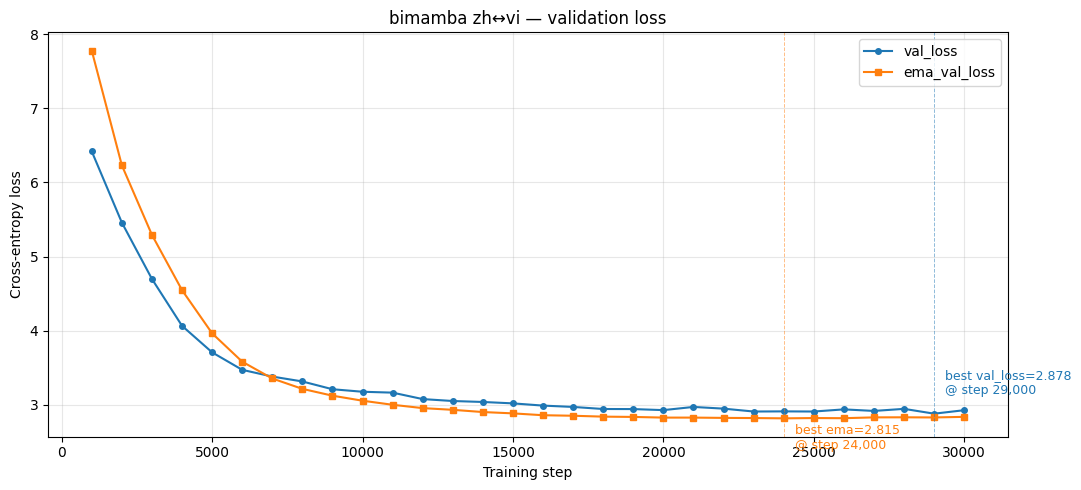

Saved: reports/mamba/figures/loss_curves_transformer.png


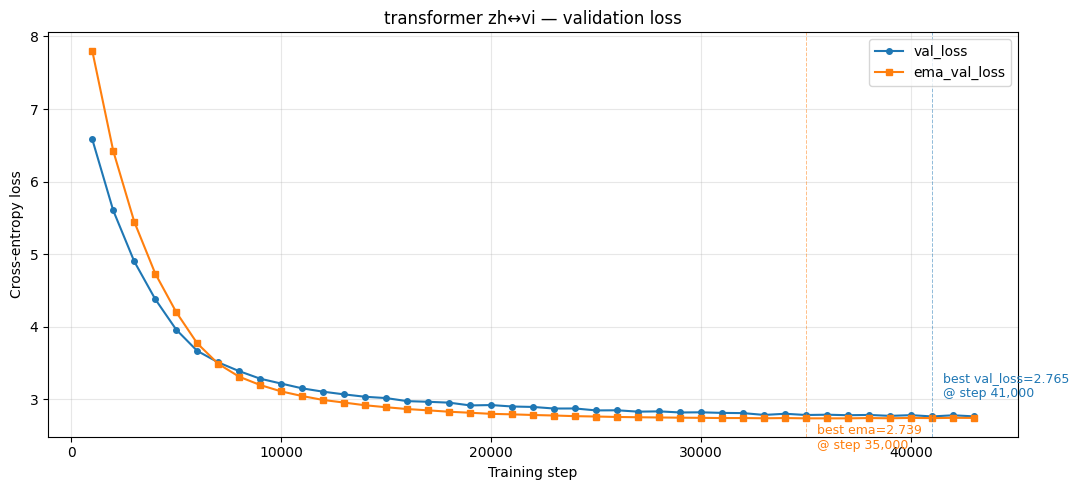

Saved: reports/mamba/figures/loss_curves_hybrid.png


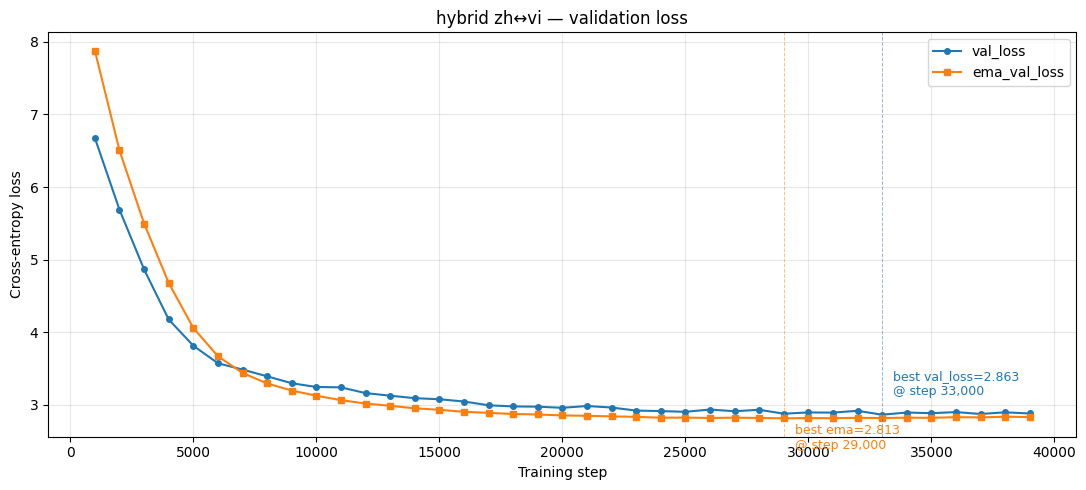

In [12]:
import matplotlib.pyplot as plt

for STDOUT_NAME, df_eval in df_eval_list:
    if len(df_eval) == 0:
        print('SKIP — không có log để vẽ loss curves (xem mục 4).')
    else:
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.plot(df_eval.step, df_eval.val_loss, marker='o', ms=4, color='C0', label='val_loss')
        if 'ema_val_loss' in df_eval:
            ax.plot(df_eval.step, df_eval.ema_val_loss, marker='s', ms=4, color='C1', label='ema_val_loss')

        bs = int(df_eval.loc[df_eval.val_loss.idxmin(), 'step'])
        bv = float(df_eval.val_loss.min())
        ax.axvline(bs, color='C0', ls='--', lw=0.7, alpha=0.5)
        ax.annotate(f'best val_loss={bv:.3f}\n@ step {bs:,}',
                    xy=(bs, bv), xytext=(8, 14), textcoords='offset points',
                    fontsize=9, color='C0')
        if 'ema_val_loss' in df_eval:
            bs2 = int(df_eval.loc[df_eval.ema_val_loss.idxmin(), 'step'])
            bv2 = float(df_eval.ema_val_loss.min())
            ax.axvline(bs2, color='C1', ls='--', lw=0.7, alpha=0.5)
            ax.annotate(f'best ema={bv2:.3f}\n@ step {bs2:,}',
                        xy=(bs2, bv2), xytext=(8, -22), textcoords='offset points',
                        fontsize=9, color='C1')

        ax.set_xlabel('Training step')
        ax.set_ylabel('Cross-entropy loss')
        ax.set_title(f'{STDOUT_NAME} zh↔vi — validation loss')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', frameon=True)
        fig.tight_layout()
        out = FIG_DIR / f'loss_curves_{STDOUT_NAME}.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        print(f'Saved: {out}')
        plt.show()

## 7. LR schedule (tái dựng giải tích)

Dùng cùng công thức `cosine_lr` của trainer + config thực tế. Không cần parse log.

Saved: reports/mamba/figures/lr_schedule_bimamba.png


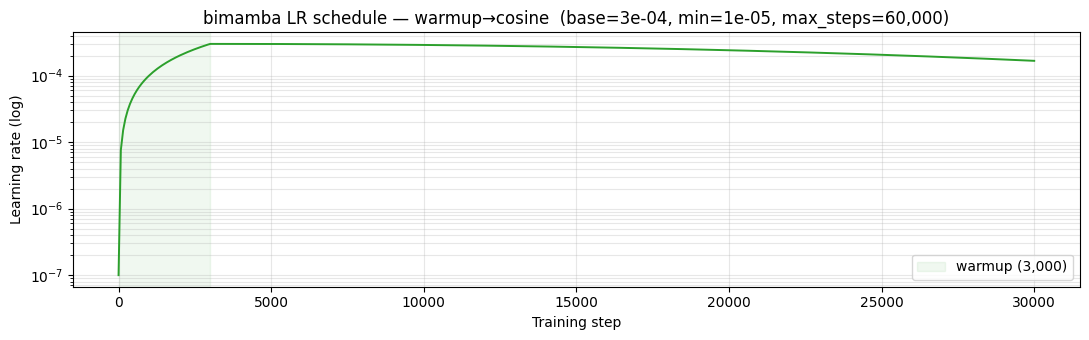

Saved: reports/mamba/figures/lr_schedule_transformer.png


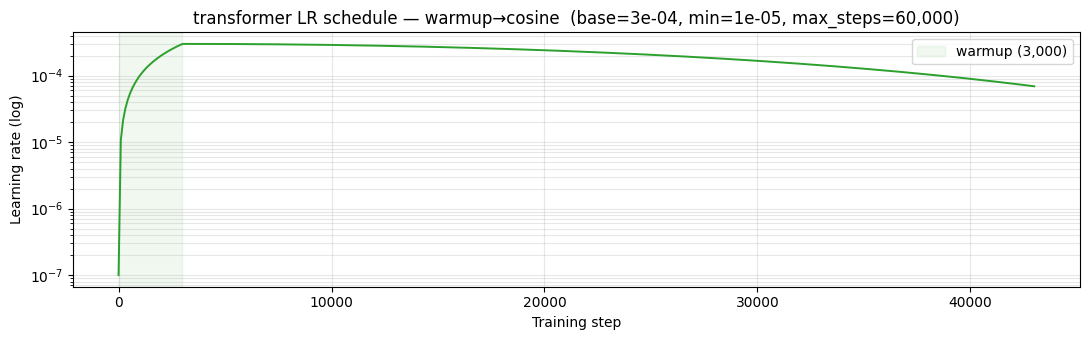

Saved: reports/mamba/figures/lr_schedule_hybrid.png


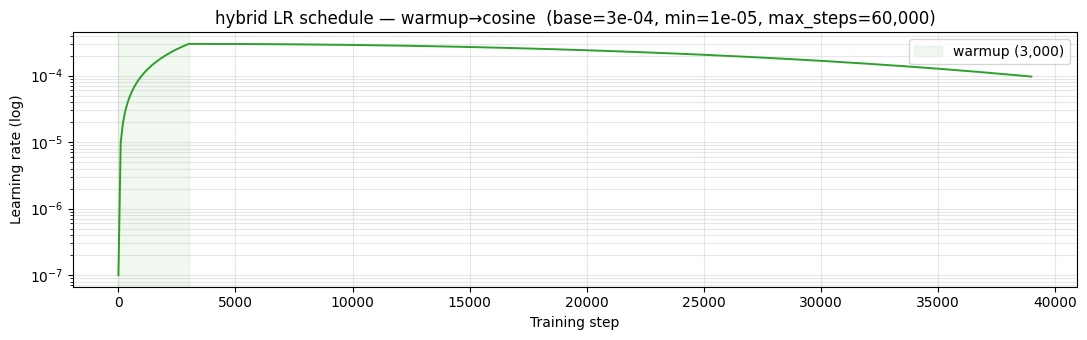

In [13]:
import math
import yaml
import numpy as np

cfg = yaml.safe_load(open(CONFIG_PATH))
tr  = cfg['train']

def cosine_lr(step, warmup, max_steps, base_lr, min_lr):
    if step < warmup:
        return base_lr * (step + 1) / max(1, warmup)
    p = (step - warmup) / max(1, max_steps - warmup)
    p = min(max(p, 0.0), 1.0)
    return min_lr + 0.5 * (base_lr - min_lr) * (1.0 + math.cos(math.pi * p))

for STDOUT_NAME, df_eval in df_eval_list:
    # Chọn endpoint = step cuối quan sát được trong log (nếu có), nếu không = max_steps.
    endpoint = int(df_eval.step.max()) if len(df_eval) else int(tr['max_steps'])
    xs = np.linspace(0, endpoint, num=400, dtype=int)
    ys = [cosine_lr(int(s), tr['warmup_steps'], tr['max_steps'], tr['lr'], tr['min_lr']) for s in xs]

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(xs, ys, color='C2', lw=1.4)
    ax.axvspan(0, tr['warmup_steps'], color='C2', alpha=0.07, label=f"warmup ({tr['warmup_steps']:,})")
    ax.set_yscale('log'); ax.set_xlabel('Training step'); ax.set_ylabel('Learning rate (log)')
    ax.set_title(f"{STDOUT_NAME} LR schedule — warmup→cosine  (base={tr['lr']:.0e}, min={tr['min_lr']:.0e}, max_steps={tr['max_steps']:,})")
    ax.grid(True, which='both', alpha=0.3); ax.legend()
    fig.tight_layout()
    out = FIG_DIR / f'lr_schedule_{STDOUT_NAME}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()


## 8. Bảng số tham số của model

Phân loại param theo từng kiến trúc — `embedding`, `encoder`, `decoder`, `final norms`.
Component label tự khớp với `MODEL_KIND` đang chọn.

In [14]:
def BUILD_MODEL(kind, model_cfg_dict):
    """Construct an empty model from `model_cfg_dict` for the given kind."""
    if kind == 'mamba':
        from bi_mamba_mt.model import BiMambaTranslator, ModelConfig
        return BiMambaTranslator(ModelConfig(**model_cfg_dict))
    if kind == 'hybrid':
        from hybrid_mt.model import HybridMambaAttentionTranslator, ModelConfig
        return HybridMambaAttentionTranslator(ModelConfig(**model_cfg_dict))
    if kind == 'transformer':
        from transformer_mt.model import TransformerTranslator, ModelConfig
        return TransformerTranslator(ModelConfig(**model_cfg_dict))
    raise ValueError(f'Unknown kind: {kind}')


def PICK_CKPT(run_dir):
    """Pick the strongest available checkpoint in priority order."""
    run_dir = Path(run_dir)
    if not run_dir.exists():
        return None
    for cand in [
        'avg_last5_ema.pt', 'best_ema.pt',
        'avg_last5.pt', 'best.pt',
        'latest_ema.pt', 'latest.pt',
        'final.pt',
    ]:
        p = run_dir / cand
        if p.exists():
            return p
    return None

In [15]:
import torch
import pandas as pd

MODEL_RUN_LIST = [
    ('mamba', Path("/home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/bi_mamba_55m")),
    ('hybrid', Path("/home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/hybrid_mamba_attention")),
    ('transformer', Path("/home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/transformer_30m"))
]
for MODEL_KIND, RUN_DIR in MODEL_RUN_LIST:
    ckpt_for_arch = PICK_CKPT(RUN_DIR)
    HAVE_CKPT = ckpt_for_arch is not None
    if not HAVE_CKPT:
        print(f'SKIP — không tìm thấy checkpoint trong {RUN_DIR}. '
              f'Phần param breakdown / BLEU / qualitative sẽ tự bỏ qua. '
              f'Train trước qua: uv run python {META["train_script"]} --config {META["config_path"]}')
        breakdown = None
        mcfg = None
    else:
        ckpt = torch.load(ckpt_for_arch, map_location='cpu', weights_only=False)
        model_cfg_dict = ckpt.get('model_cfg', yaml.safe_load(open(CONFIG_PATH))['model'])
        model = BUILD_MODEL(MODEL_KIND, model_cfg_dict)
        mcfg = type(model).__module__ and model.cfg

        def _sum(prefix):
            return sum(p.numel() for n, p in model.named_parameters() if n.startswith(prefix))

        # Param-prefix scheme per architecture (matches model.py code).
        if MODEL_KIND == 'mamba':
            stats = {
                'embedding (tied with lm_head)':    _sum('embedding.'),
                'encoder (Bi-Mamba × N)':           _sum('encoder_layers.'),
                'decoder (Mamba + cross-attn × N)': _sum('decoder_layers.'),
                'final norms':                      _sum('encoder_norm.') + _sum('decoder_norm.'),
            }
        elif MODEL_KIND == 'hybrid':
            stats = {
                'embedding (tied with lm_head)':    _sum('embedding.'),
                'encoder (Bi-Mamba × N + FFN)':     _sum('encoder_layers.'),
                'decoder (Transformer × N)':        _sum('decoder.'),
                'final norms':                      _sum('encoder_norm.'),
            }
        elif MODEL_KIND == 'transformer':
            stats = {
                'embedding (tied with lm_head)':    _sum('embedding.'),
                'encoder (Transformer × N)':        _sum('encoder.'),
                'decoder (Transformer × N)':        _sum('decoder.'),
                'final norms':                      0,  # built into nn.TransformerEncoder/Decoder via norm_first
            }
        total = sum(p.numel() for p in model.parameters())
        other = total - sum(stats.values())
        if other > 0:
            stats['other'] = other

        breakdown = pd.DataFrame(
            [(k, v, 100*v/total) for k, v in stats.items()] + [('TOTAL', total, 100.0)],
            columns=['component', 'params', '% of total']
        )
        breakdown['params'] = breakdown['params'].map(lambda x: f'{x:,}')

        cfg_for_print = model.cfg
        if MODEL_KIND == 'mamba':
            print(f'Architecture: d_model={cfg_for_print.d_model}, '
                  f'encoder={cfg_for_print.n_encoder_layers}, '
                  f'decoder={cfg_for_print.n_decoder_layers}, '
                  f'd_ff={cfg_for_print.d_ff}, vocab={cfg_for_print.vocab_size}')
        elif MODEL_KIND == 'hybrid':
            print(f'Architecture: d_model={cfg_for_print.d_model}, '
                  f'encoder={cfg_for_print.n_encoder_layers} (Bi-Mamba+FFN({cfg_for_print.encoder_d_ff})), '
                  f'decoder={cfg_for_print.n_decoder_layers} (Transformer, FFN({cfg_for_print.decoder_d_ff})), '
                  f'vocab={cfg_for_print.vocab_size}')
        elif MODEL_KIND == 'transformer':
            print(f'Architecture: d_model={cfg_for_print.d_model}, '
                  f'encoder={cfg_for_print.n_encoder_layers}, '
                  f'decoder={cfg_for_print.n_decoder_layers}, '
                  f'd_ff={cfg_for_print.d_ff}, vocab={cfg_for_print.vocab_size}')

        breakdown.to_csv(REPORT_DIR / f'param_breakdown_{MODEL_KIND}.csv', index=False)
    print(breakdown)

Architecture: d_model=384, encoder=5, decoder=5, d_ff=960, vocab=16000
                          component      params  % of total
0     embedding (tied with lm_head)   6,144,000   18.944103
1            encoder (Bi-Mamba × N)  14,813,760   45.676008
2  decoder (Mamba + cross-attn × N)  11,472,960   35.375152
3                       final norms       1,536    0.004736
4                             TOTAL  32,432,256  100.000000
Architecture: d_model=384, encoder=5 (Bi-Mamba+FFN(960)), decoder=5 (Transformer, FFN(1536)), vocab=16000
                       component      params  % of total
0  embedding (tied with lm_head)   6,144,000   18.736131
1   encoder (Bi-Mamba × N + FFN)  14,813,760   45.174568
2      decoder (Transformer × N)  11,833,728   36.086959
3                    final norms         768    0.002342
4                          TOTAL  32,792,256  100.000000
Architecture: d_model=384, encoder=5, decoder=5, d_ff=2048, vocab=16000
                       component      params  % o

/home/oslamelon/Downloads/AI_NLP/NLP_DHM/src/transformer_mt/model.py:93: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


## 8b. Thống kê dataset

Thống kê đầy đủ trên dữ liệu thực tế đã chuẩn bị xong (sau khi `prepare_data.py`
đã được chạy). Sử dụng:
* **`data/processed/{train,valid,test}.jsonl`** — file kết quả cuối cùng đã
  qua filter + cap + split. Đây là dữ liệu mà model được train trên đó.
* **`data/raw/<source>.zip`** — các archive OPUS đã download (nếu còn). Dùng
  để đếm số cặp gốc của TỪNG nguồn (TED2020 / WikiMatrix / bible-uedin / ...)
  trước khi lọc + cap.

Nếu bạn đã xoá `data/raw/` để tiết kiệm dung lượng, phần "per-source" sẽ tự
skip (chỉ thiếu 1 biểu đồ; phần còn lại vẫn chạy).


### 8b.1. Train / Valid / Test split

Total pairs: 135,279
  train:    125,279  ( 92.6%)
  valid:      5,000  (  3.7%)
  test :      5,000  (  3.7%)
Saved: reports/mamba/figures/split_sizes.png


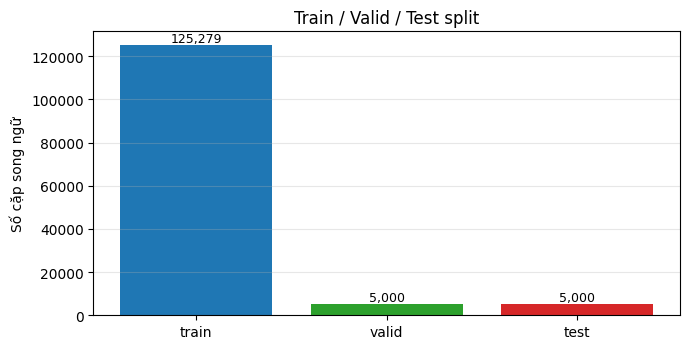

In [16]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PROC = Path('data/processed')

def _read_jsonl(p):
    if not p.exists():
        return []
    out = []
    with open(p, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line: out.append(json.loads(line))
    return out

splits = {'train': _read_jsonl(DATA_PROC/'train.jsonl'),
          'valid': _read_jsonl(DATA_PROC/'valid.jsonl'),
          'test':  _read_jsonl(DATA_PROC/'test.jsonl')}
sizes = {k: len(v) for k, v in splits.items()}
total = sum(sizes.values())
print(f'Total pairs: {total:,}')
for k, n in sizes.items():
    print(f'  {k:5s}: {n:>10,}  ({100*n/max(total,1):5.1f}%)')

fig, ax = plt.subplots(figsize=(7, 3.6))
ks = list(sizes.keys()); vs = [sizes[k] for k in ks]
bars = ax.bar(ks, vs, color=['C0','C2','C3'])
for b, v in zip(bars, vs):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Số cặp song ngữ')
ax.set_title('Train / Valid / Test split')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
out = FIG_DIR / 'split_sizes.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()


### 8b.2. Số cặp theo nguồn (per-source)

Đếm trực tiếp từ archive OPUS trong `data/raw/*.zip`:
* **raw**: số cặp gốc trong file zip OPUS, không filter.
* **after_filter**: số cặp pass `pair_ok` + `looks_like_zh`/`looks_like_vi` +
  ratio bounds — đúng pipeline của `prepare_data.py`.
* **after_cap**: áp dụng tiếp `data.max_pairs_per_source` (cap mỗi nguồn).


       source               zip     raw  after_filter  after_cap      cap
      ted2020       ted2020.zip   15994         15424      15424      NaN
   wikimatrix    wikimatrix.zip   89445         81905      81905 100000.0
  bible_uedin   bible_uedin.zip  124396        120680       6000   6000.0
opensubtitles opensubtitles.zip 1777340       1585394      20000  20000.0
         nllb          nllb.zip 8045074       7179657      20000  20000.0
Saved: reports/mamba/figures/per_source_counts.png


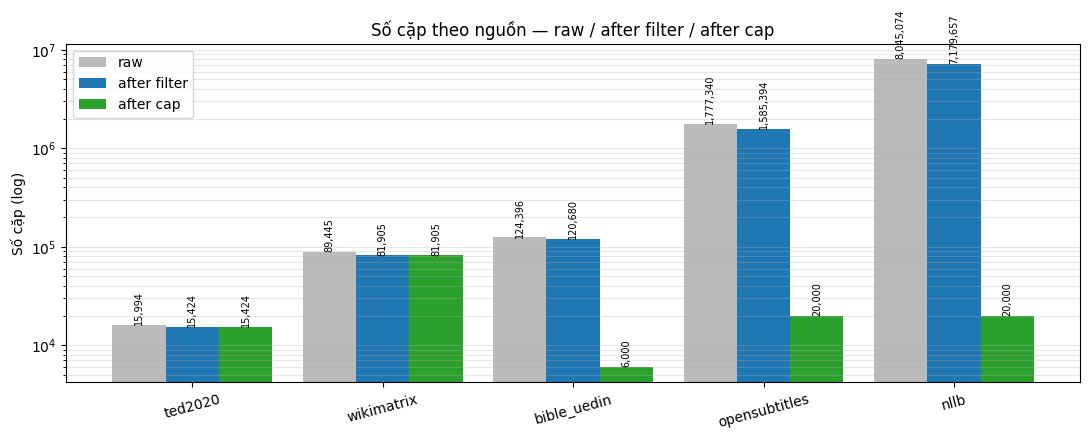

In [17]:
import io, zipfile, sys
sys.path.insert(0, 'src')
from bi_mamba_mt.data import basic_clean, pair_ok, looks_like_zh, looks_like_vi
import yaml

cfg = yaml.safe_load(open(CONFIG_PATH))
data_cfg = cfg['data']
RAW_DIR = Path(data_cfg.get('raw_dir', 'data/raw'))
caps = data_cfg.get('max_pairs_per_source') or {}

# (source_key, zip filename pattern, vi_member, zh_member)
SOURCES = [
    ('ted2020',     'TED2020',      '.vi-zh.vi',     '.vi-zh.zh'),
    ('wikimatrix',  'WikiMatrix',   '.vi-zh.vi',     '.vi-zh.zh'),
    ('bible_uedin', 'bible-uedin',  '.vi-zh.vi',     '.vi-zh.zh'),
    ('opensubtitles','OpenSubtitles','.vi-zh_cn.vi', '.vi-zh_cn.zh_cn'),
    ('nllb',        'NLLB',         '.vi-zh.vi',     '.vi-zh.zh'),
]

def _count(zip_path, vi_pat, zh_pat):
    raw = passed = 0
    with zipfile.ZipFile(zip_path) as z:
        names = z.namelist()
        vi_m = next((n for n in names if n.endswith(vi_pat)), None)
        zh_m = next((n for n in names if n.endswith(zh_pat)), None)
        if not (vi_m and zh_m): return 0, 0
        with z.open(vi_m) as fv, z.open(zh_m) as fz:
            for vi_line, zh_line in zip(io.TextIOWrapper(fv, encoding='utf-8'),
                                         io.TextIOWrapper(fz, encoding='utf-8')):
                vi = basic_clean(vi_line); zh = basic_clean(zh_line)
                if not vi or not zh: continue
                raw += 1
                # Same filter pipeline as prepare_data.py
                if not pair_ok(zh=zh, vi=vi,
                               min_zh_vi_ratio=data_cfg.get('min_zh_vi_ratio', 0.10),
                               max_zh_vi_ratio=data_cfg.get('max_zh_vi_ratio', 1.20),
                               script_check=data_cfg.get('script_check', True),
                               min_len=data_cfg.get('min_len', 1),
                               max_chars=data_cfg.get('max_len', 250)):
                    continue
                passed += 1
    return raw, passed

rows = []
for key, zname, vi_pat, zh_pat in SOURCES:
    # find zip
    # Zips are saved by prepare_data.py as <key>.zip (lowercase).
    cand = []
    by_key = RAW_DIR / f'{key}.zip'
    if by_key.exists(): cand = [by_key]
    else:
        cand = [p for p in RAW_DIR.glob(f'*{zname}*') if p.suffix == '.zip']
    if not cand:
        rows.append({'source': key, 'zip': None, 'raw': None, 'after_filter': None,
                     'after_cap': None, 'cap': caps.get(key)})
        continue
    zp = cand[0]
    try:
        raw, passed = _count(zp, vi_pat, zh_pat)
    except Exception as e:
        print(f'  {key}: failed to count ({e})')
        raw, passed = None, None
    cap = caps.get(key)
    capped = passed if cap is None else (None if passed is None else min(passed, int(cap)))
    rows.append({'source': key, 'zip': zp.name, 'raw': raw, 'after_filter': passed,
                 'after_cap': capped, 'cap': cap})

dfs = pd.DataFrame(rows)
print(dfs.to_string(index=False))
dfs.to_csv(REPORT_DIR / 'per_source_counts.csv', index=False)

# Bar chart - chỉ các nguồn có data
plotable = dfs.dropna(subset=['after_filter']).copy()
if len(plotable) > 0:
    fig, ax = plt.subplots(figsize=(11, 4.5))
    import numpy as np
    x = np.arange(len(plotable)); w = 0.28
    ax.bar(x - w, plotable['raw'].fillna(0),           w, label='raw',           color='#bbb')
    ax.bar(x,     plotable['after_filter'].fillna(0),  w, label='after filter',  color='C0')
    ax.bar(x + w, plotable['after_cap'].fillna(0),     w, label='after cap',     color='C2')
    ax.set_xticks(x); ax.set_xticklabels(plotable['source'], rotation=15)
    ax.set_yscale('log')
    ax.set_ylabel('Số cặp (log)')
    ax.set_title('Số cặp theo nguồn — raw / after filter / after cap')
    ax.legend(); ax.grid(True, axis='y', which='both', alpha=0.3)
    for i, r in enumerate(plotable.itertuples()):
        for j, (col, off) in enumerate([('raw', -w), ('after_filter', 0), ('after_cap', w)]):
            v = getattr(r, col)
            if v is not None and v > 0:
                ax.text(i + off, v, f'{int(v):,}', ha='center', va='bottom', fontsize=7, rotation=90)
    fig.tight_layout()
    out = FIG_DIR / 'per_source_counts.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved: {out}')
    plt.show()
else:
    print('Không có archive trong data/raw/ — bỏ qua biểu đồ per-source.')


### 8b.3. Phân phối độ dài câu (character-level, train set)

Histogram độ dài (số ký tự) của câu zh và câu vi trong tập train. Chỉ hiện
trong khoảng [0, 250] vì đây là `max_len` của filter.

Char-length stats (train set):
  zh: {'count': 125279, 'mean': 32.793437048507734, 'median': 27.0, 'p95': 81.0, 'max': 432}
  vi: {'count': 125279, 'mean': 98.39633937052498, 'median': 84.0, 'p95': 226.0, 'max': 898}
Saved: reports/mamba/figures/length_dist_chars.png


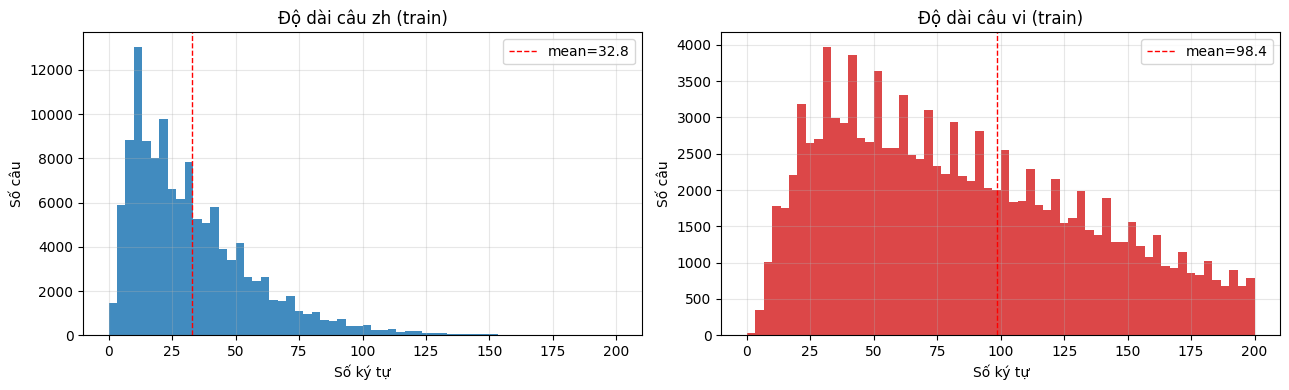

In [18]:
import numpy as np

train = splits['train']
zh_lens = np.array([len(p['zh']) for p in train])
vi_lens = np.array([len(p['vi']) for p in train])

def _stats(arr):
    return {
        'count': len(arr),
        'mean':  float(arr.mean()) if len(arr) else 0,
        'median': float(np.median(arr)) if len(arr) else 0,
        'p95':   float(np.percentile(arr, 95)) if len(arr) else 0,
        'max':   int(arr.max()) if len(arr) else 0,
    }
print('Char-length stats (train set):')
print('  zh:', _stats(zh_lens))
print('  vi:', _stats(vi_lens))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(zh_lens, bins=60, range=(0, 200), color='C0', alpha=0.85)
axes[0].set_xlabel('Số ký tự'); axes[0].set_ylabel('Số câu'); axes[0].set_title('Độ dài câu zh (train)')
axes[0].axvline(zh_lens.mean(), color='red', ls='--', lw=1, label=f'mean={zh_lens.mean():.1f}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(vi_lens, bins=60, range=(0, 200), color='C3', alpha=0.85)
axes[1].set_xlabel('Số ký tự'); axes[1].set_ylabel('Số câu'); axes[1].set_title('Độ dài câu vi (train)')
axes[1].axvline(vi_lens.mean(), color='red', ls='--', lw=1, label=f'mean={vi_lens.mean():.1f}')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.tight_layout()
out = FIG_DIR / 'length_dist_chars.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()


### 8b.4. Phân phối tỉ lệ độ dài zh/vi

Tỉ lệ `len(zh)/len(vi)` cho từng cặp. Empirically với OPUS-clean tỉ lệ này
nằm trong khoảng 0.20–0.60 (vi dài hơn zh do có khoảng trắng + dấu thanh).
Filter mặc định ở `prepare_data.py` cho qua khoảng 0.10–1.20.

zh/vi length ratio — mean=0.344, median=0.315, p5=0.200, p95=0.577
Saved: reports/mamba/figures/length_ratio.png


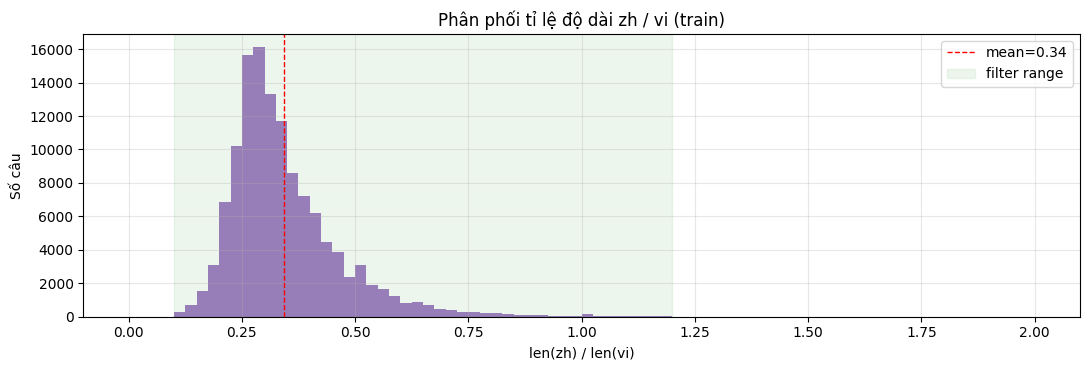

In [19]:
ratios = zh_lens / np.maximum(vi_lens, 1)
ratios = ratios[(ratios >= 0.0) & (ratios <= 2.5)]   # clip outliers cho đỡ vỡ chart
print(f'zh/vi length ratio — mean={ratios.mean():.3f}, median={np.median(ratios):.3f}, '
      f'p5={np.percentile(ratios, 5):.3f}, p95={np.percentile(ratios, 95):.3f}')

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.hist(ratios, bins=80, range=(0, 2), color='C4', alpha=0.85)
ax.axvline(ratios.mean(), color='red', ls='--', lw=1, label=f'mean={ratios.mean():.2f}')
ax.axvspan(data_cfg.get('min_zh_vi_ratio', 0.10), data_cfg.get('max_zh_vi_ratio', 1.20),
           color='green', alpha=0.07, label='filter range')
ax.set_xlabel('len(zh) / len(vi)'); ax.set_ylabel('Số câu')
ax.set_title('Phân phối tỉ lệ độ dài zh / vi (train)')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
out = FIG_DIR / 'length_ratio.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved: {out}')
plt.show()


### 8b.5. Phân phối độ dài câu (token-level, sau SentencePiece)

Vì model nhận token chứ không phải ký tự, đây là histogram quan trọng nhất
khi đánh giá `max_src_len` / `max_tgt_len`. Random sample 5000 cặp cho nhanh
(đủ chính xác đại diện).

Vocab size: 16,000

Token-length stats (sample 5000):
  zh: mean=22.2  median=18  p95=52  max=148
  vi: mean=27.4  median=23  p95=62  max=161

Fertility (chars / token):
  zh: 1.44
  vi: 3.54

Saved: reports/mamba/figures/length_dist_tokens.png


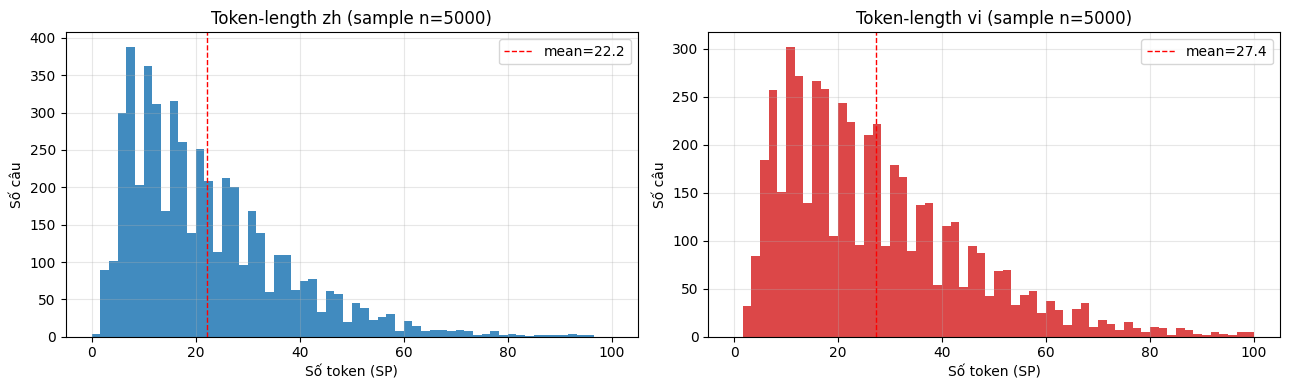

In [20]:
from mt_base.tokenizer import Tokenizer
import random

spm_path = TOKEN_DIR / 'spm.model'
if not spm_path.exists():
    print(f'SKIP — không tìm thấy {spm_path}.')
else:
    tok = Tokenizer(str(spm_path))
    print(f'Vocab size: {tok.vocab_size:,}')

    n_sample = min(5000, len(train))
    sample = random.Random(42).sample(train, n_sample)
    zh_tok_lens = np.array([len(tok.encode(p['zh'])) for p in sample])
    vi_tok_lens = np.array([len(tok.encode(p['vi'])) for p in sample])

    print(f'\nToken-length stats (sample {n_sample}):')
    print(f'  zh: mean={zh_tok_lens.mean():.1f}  median={np.median(zh_tok_lens):.0f}  p95={np.percentile(zh_tok_lens,95):.0f}  max={zh_tok_lens.max()}')
    print(f'  vi: mean={vi_tok_lens.mean():.1f}  median={np.median(vi_tok_lens):.0f}  p95={np.percentile(vi_tok_lens,95):.0f}  max={vi_tok_lens.max()}')
    print(f'\nFertility (chars / token):')
    print(f'  zh: {(np.array([len(p["zh"]) for p in sample])/np.maximum(zh_tok_lens,1)).mean():.2f}')
    print(f'  vi: {(np.array([len(p["vi"]) for p in sample])/np.maximum(vi_tok_lens,1)).mean():.2f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(zh_tok_lens, bins=60, range=(0, 100), color='C0', alpha=0.85)
    axes[0].set_xlabel('Số token (SP)'); axes[0].set_ylabel('Số câu')
    axes[0].set_title(f'Token-length zh (sample n={n_sample})')
    axes[0].axvline(zh_tok_lens.mean(), color='red', ls='--', lw=1, label=f'mean={zh_tok_lens.mean():.1f}')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].hist(vi_tok_lens, bins=60, range=(0, 100), color='C3', alpha=0.85)
    axes[1].set_xlabel('Số token (SP)'); axes[1].set_ylabel('Số câu')
    axes[1].set_title(f'Token-length vi (sample n={n_sample})')
    axes[1].axvline(vi_tok_lens.mean(), color='red', ls='--', lw=1, label=f'mean={vi_tok_lens.mean():.1f}')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    out = FIG_DIR / 'length_dist_tokens.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print(f'\nSaved: {out}')
    plt.show()

### 8b.6. Bảng tổng hợp dataset

Bảng tổng hợp các con số quan trọng — paste thẳng vào báo cáo.

In [21]:
dataset_summary = {
    'train pairs':              sizes['train'],
    'valid pairs':              sizes['valid'],
    'test pairs':               sizes['test'],
    'total':                    sum(sizes.values()),
    'zh char-length mean':      f'{zh_lens.mean():.1f}',
    'zh char-length p95':       f'{np.percentile(zh_lens, 95):.0f}',
    'vi char-length mean':      f'{vi_lens.mean():.1f}',
    'vi char-length p95':       f'{np.percentile(vi_lens, 95):.0f}',
    'zh/vi ratio mean':         f'{ratios.mean():.3f}',
    'preset':                   data_cfg.get('preset', '?'),
    'max_pairs_per_source':     data_cfg.get('max_pairs_per_source'),
    'config max_train_pairs':   data_cfg.get('max_train_pairs'),
}
ds = pd.DataFrame([(k, v) for k, v in dataset_summary.items()],
                  columns=['metric', 'value'])
ds.to_csv(REPORT_DIR / 'dataset_summary.csv', index=False)
ds


,metric,value
0,train pairs,125279
1,valid pairs,5000
2,test pairs,5000
3,total,135279
4,zh char-length mean,32.8
5,zh char-length p95,81
6,vi char-length mean,98.4
7,vi char-length p95,226
8,zh/vi ratio mean,0.344
9,preset,everyday


## 9. BLEU + chrF cho từng checkpoint của model đang chọn

Eval mỗi checkpoint variant (`latest`, `best`, `avg_last5`, EMA versions) bằng
`META['eval_script']` (auto-dispatch theo `MODEL_KIND`). Per-length-bucket breakdown
được bật mặc định nếu script hỗ trợ.

In [22]:
import os, re, json, subprocess
from pathlib import Path

RESULTS_PATH_LIST = []
for KIND, info in _REGISTRY.items():
    RUN_DIR = Path(info['run_dir'])
    ckpt_for_arch = PICK_CKPT(RUN_DIR)
    HAVE_CKPT = ckpt_for_arch is not None

    if not HAVE_CKPT:
        print(f'SKIP [{KIND}] — không có checkpoint trong {RUN_DIR}.')
        continue

    current_report_dir = Path('reports') / KIND
    current_report_dir.mkdir(parents=True, exist_ok=True)
    RESULTS_PATH = current_report_dir / 'eval_results.json'
    TAGGED_RESULTS_PATH = current_report_dir / f'eval_results_{REPORT_SLUG}.json'

    CURRENT_CONFIG = info['config_path']
    current_cfg = yaml.safe_load(open(CURRENT_CONFIG))
    current_full_eval_n = int(current_cfg.get('eval', {}).get('num_samples', REPORT_NUM_SAMPLES))

    EVAL_N = REPORT_NUM_SAMPLES
    EVAL_BEAM = REPORT_BEAM_EFFECTIVE
    EVAL_SAMPLE_SEED = REPORT_SAMPLE_SEED
    EVAL_MAX_LEN = REPORT_MAX_DECODE_LEN_EFFECTIVE
    EVAL_SCRIPT = info['eval_script']

    CKPTS = [
        ('final',          RUN_DIR / 'final.pt'),
        ('latest',         RUN_DIR / 'latest.pt'),
        ('latest_ema',     RUN_DIR / 'latest_ema.pt'),
        ('best',           RUN_DIR / 'best.pt'),
        ('best_ema',       RUN_DIR / 'best_ema.pt'),
        ('avg_last5',      RUN_DIR / 'avg_last5.pt'),
        ('avg_last5_ema',  RUN_DIR / 'avg_last5_ema.pt'),
    ]
    CKPTS = [(n, p) for n, p in CKPTS if p.exists()]

    help_out = subprocess.run(['uv', 'run', 'python', EVAL_SCRIPT, '--help'], capture_output=True, text=True).stdout
    SUPPORTS_BUCKETS = '--length-buckets' in help_out
    SUPPORTS_NONSTRICT = '--allow-non-strict' in help_out

    pat = re.compile(r'\[(\w+)\]\s+n=(\d+)\s+BLEU=([\d.]+)\s+chrF=([\d.]+)\s+\(beam=(\d+),\s*lp=([\d.]+)\)')
    bucket_pat = re.compile(r'\s*bucket=(\w+)\s+n=(\d+)\s+BLEU=([\d.]+)\s+chrF=([\d.]+)')

    def _run_eval(label, args):
        print(f'\n=== {KIND} : {label} ===')
        runtime_out = current_report_dir / f'runtime_{label}_{REPORT_SLUG}.json'
        cmd = [
            'uv', 'run', 'python', EVAL_SCRIPT,
            '--config', CURRENT_CONFIG,
            '--num-samples', str(EVAL_N),
            '--beam-size', str(EVAL_BEAM),
            '--max-decode-len', str(EVAL_MAX_LEN),
            '--length-penalty-zh2vi', str(REPORT_LENGTH_PENALTY['zh2vi']),
            '--length-penalty-vi2zh', str(REPORT_LENGTH_PENALTY['vi2zh']),
            '--runtime-out', str(runtime_out),
        ] + args
        if EVAL_SAMPLE_SEED is not None:
            cmd += ['--sample-seed', str(EVAL_SAMPLE_SEED)]
        if SUPPORTS_BUCKETS:
            cmd.append('--length-buckets')
        if SUPPORTS_NONSTRICT and any('avg' in str(a) for a in args):
            cmd.append('--allow-non-strict')

        print('  $', ' '.join(cmd))
        out = subprocess.run(cmd, capture_output=True, text=True)
        print(out.stdout[-2000:])
        if out.returncode != 0:
            print('STDERR:', out.stderr[-1000:])

        parsed = {}
        current_dir = None
        for line in out.stdout.splitlines():
            m = pat.search(line)
            if m:
                d, n, bleu, chrf, beam, lp = m.groups()
                current_dir = d
                parsed[d] = {
                    'n': int(n),
                    'bleu': float(bleu),
                    'chrf': float(chrf),
                    'beam': int(beam),
                    'lp': float(lp),
                    'buckets': {},
                }
                continue
            mb = bucket_pat.search(line)
            if mb and current_dir:
                bname, bn, bb, bc = mb.groups()
                parsed[current_dir]['buckets'][bname] = {
                    'n': int(bn), 'bleu': float(bb), 'chrf': float(bc),
                }

        runtime_data = None
        if runtime_out.exists():
            try:
                runtime_data = json.loads(runtime_out.read_text())
            except Exception:
                runtime_data = None
        return parsed, runtime_data

    results = {
        '_meta': {
            'model_kind': KIND,
            'eval_label': REPORT_LABEL,
            'mode_slug': REPORT_SLUG,
            'num_samples': EVAL_N,
            'sample_seed': EVAL_SAMPLE_SEED,
            'beam_size': EVAL_BEAM,
            'max_decode_len': EVAL_MAX_LEN,
            'length_penalty': REPORT_LENGTH_PENALTY,
            'length_buckets': SUPPORTS_BUCKETS,
            'full_eval_num_samples': current_full_eval_n,
        }
    }
    runtime_summary = {'_meta': dict(results['_meta']), 'by_checkpoint': {}}

    for name, ckpt_path in CKPTS:
        parsed, runtime_data = _run_eval(name, ['--checkpoint', str(ckpt_path)])
        results[name] = parsed
        if runtime_data is not None:
            runtime_summary['by_checkpoint'][name] = runtime_data

    payload = json.dumps(results, indent=2, ensure_ascii=False)
    RESULTS_PATH.write_text(payload)
    TAGGED_RESULTS_PATH.write_text(payload)
    print(f'\nSaved {RESULTS_PATH}')
    print(f'Saved {TAGGED_RESULTS_PATH}')

    runtime_path = current_report_dir / 'runtime_summary.json'
    tagged_runtime_path = current_report_dir / f'runtime_summary_{REPORT_SLUG}.json'
    runtime_payload = json.dumps(runtime_summary, indent=2, ensure_ascii=False)
    runtime_path.write_text(runtime_payload)
    tagged_runtime_path.write_text(runtime_payload)
    print(f'Saved {runtime_path}')
    print(f'Saved {tagged_runtime_path}')

    RESULTS_PATH_LIST.append(RESULTS_PATH)



=== mamba : final ===
  $ uv run python scripts/evaluate.py --config configs/bi_mamba_55m.yaml --num-samples 300 --beam-size 1 --max-decode-len 256 --length-penalty-zh2vi 1.0 --length-penalty-vi2zh 0.9 --runtime-out reports/mamba/runtime_final_draft.json --checkpoint runs/bi_mamba_55m/final.pt --sample-seed 42 --length-buckets
Loading checkpoint runs/bi_mamba_55m/final.pt
Eval mode: DRAFT METRICS | subset=random_seeded (300/5000, seed=42) | beam=1 | max_len=256
[zh2vi] n=300 BLEU=12.68 chrF=37.79 (beam=1, lp=1.00)
    bucket=short  n=118   BLEU=2.60 chrF=24.50
    bucket=medium n=119   BLEU=22.04 chrF=42.99
    bucket=long   n=63    BLEU=19.96 chrF=39.08
[vi2zh] n=300 BLEU=17.85 chrF=21.03 (beam=1, lp=0.90)
    bucket=short  n=14    BLEU=0.66 chrF=3.82
    bucket=medium n=72    BLEU=9.18 chrF=14.01
    bucket=long   n=214   BLEU=19.65 chrF=22.10
Saved runtime metadata to reports/mamba/runtime_final_draft.json


=== mamba : latest ===
  $ uv run python scripts/evaluate.py --config conf

## 10. Bar chart: BLEU + chrF theo checkpoint (cả 2 chiều)

Saved: reports/mamba/figures/bleu_chrf_per_ckpt.png
Saved: reports/mamba/figures/bleu_chrf_per_ckpt_draft.png


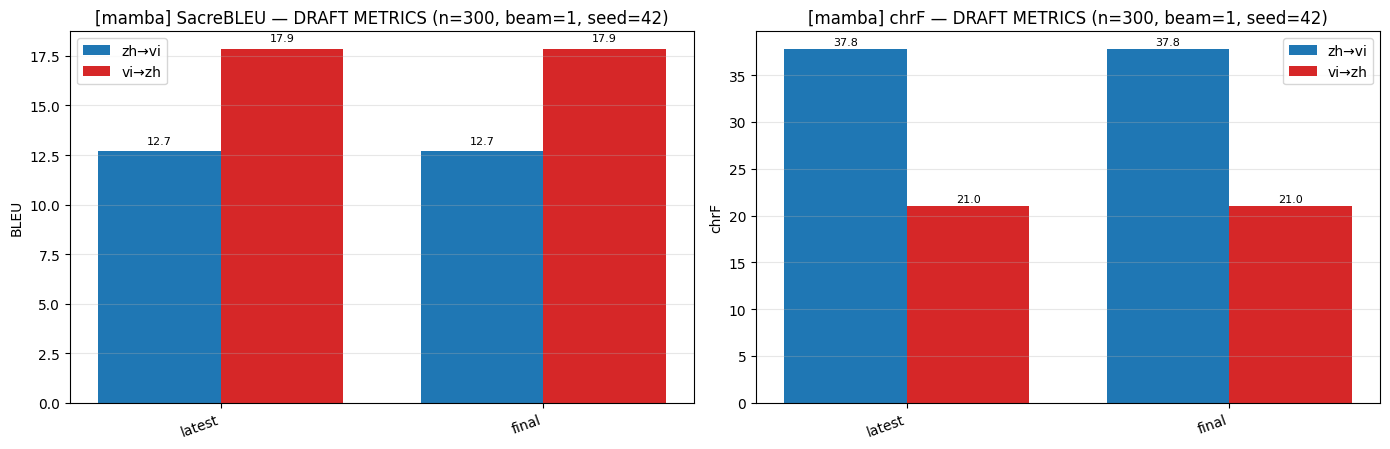

Saved: reports/hybrid/figures/bleu_chrf_per_ckpt.png
Saved: reports/hybrid/figures/bleu_chrf_per_ckpt_draft.png


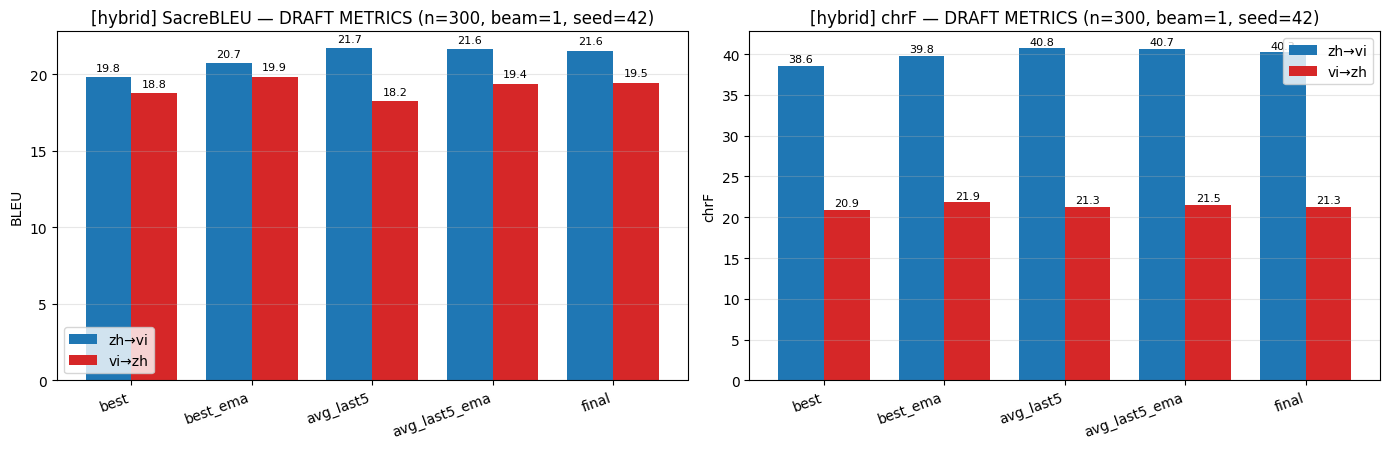

Saved: reports/transformer/figures/bleu_chrf_per_ckpt.png
Saved: reports/transformer/figures/bleu_chrf_per_ckpt_draft.png


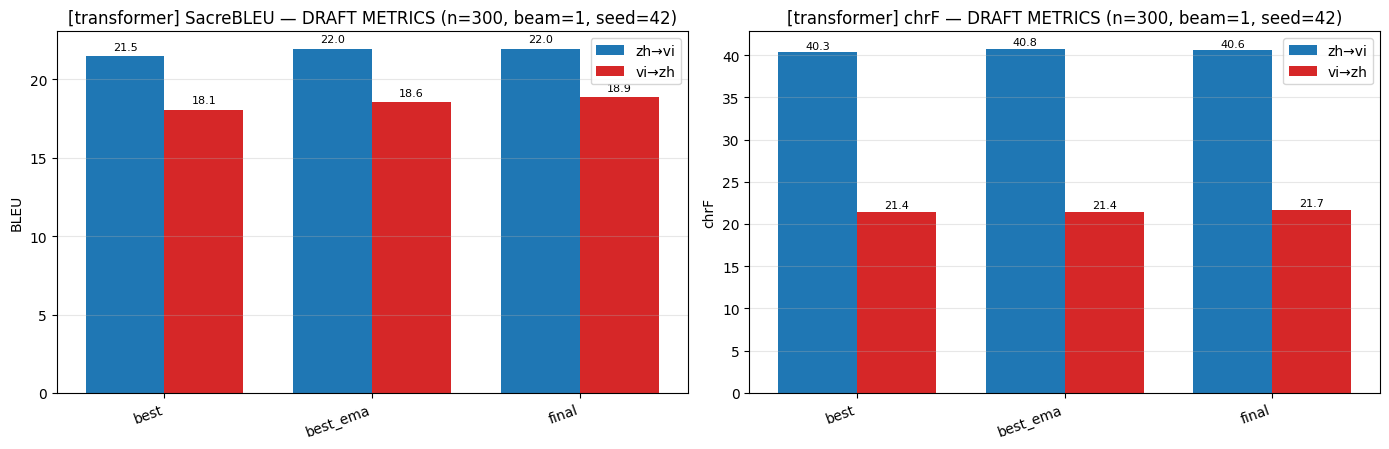

In [23]:
import json
import numpy as np
import matplotlib.pyplot as plt

for RESULTS_PATH in RESULTS_PATH_LIST:
    current_model_kind = RESULTS_PATH.parts[-2]
    current_report_dir = RESULTS_PATH.parent
    current_fig_dir = current_report_dir / 'figures'
    current_fig_dir.mkdir(parents=True, exist_ok=True)

    results = json.loads(RESULTS_PATH.read_text())
    meta = results.get('_meta', {})
    run_label = meta.get('eval_label', 'METRICS')
    mode_slug = meta.get('mode_slug', 'eval')
    title_suffix = (
        f"{run_label} (n={meta.get('num_samples', '?')}, "
        f"beam={meta.get('beam_size', '?')}, seed={meta.get('sample_seed', 'none')})"
    )
    if not results:
        print(f'SKIP — chưa có results cho {current_model_kind}, bỏ qua bar chart.')
    else:
        plotting_order = []
        plotting_zh2vi_bleu = []
        plotting_vi2zh_bleu = []
        plotting_zh2vi_chrf = []
        plotting_vi2zh_chrf = []

        for k in [
            'latest', 'latest_ema',
            'best', 'best_ema',
            'avg_last5', 'avg_last5_ema',
            'final',
        ]:
            if k in results:
                zh2vi_b = results[k].get('zh2vi', {}).get('bleu', None)
                vi2zh_b = results[k].get('vi2zh', {}).get('bleu', None)
                zh2vi_c = results[k].get('zh2vi', {}).get('chrf', None)
                vi2zh_c = results[k].get('vi2zh', {}).get('chrf', None)

                if any(v is not None for v in [zh2vi_b, vi2zh_b, zh2vi_c, vi2zh_c]):
                    plotting_order.append(k)
                    plotting_zh2vi_bleu.append(zh2vi_b if zh2vi_b is not None else np.nan)
                    plotting_vi2zh_bleu.append(vi2zh_b if vi2zh_b is not None else np.nan)
                    plotting_zh2vi_chrf.append(zh2vi_c if zh2vi_c is not None else np.nan)
                    plotting_vi2zh_chrf.append(vi2zh_c if vi2zh_c is not None else np.nan)

        if not plotting_order:
            print(f'SKIP — no valid scores to plot for {current_model_kind} from {RESULTS_PATH.name}.')
            continue

        x = np.arange(len(plotting_order)); w = 0.38
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

        ax = axes[0]
        ax.bar(x - w/2, plotting_zh2vi_bleu, w, label='zh→vi', color='C0')
        ax.bar(x + w/2, plotting_vi2zh_bleu, w, label='vi→zh', color='C3')
        for i, v in enumerate(plotting_zh2vi_bleu):
            if not np.isnan(v):
                ax.text(i - w/2, v + 0.4, f'{v:.1f}', ha='center', fontsize=8)
        for i, v in enumerate(plotting_vi2zh_bleu):
            if not np.isnan(v):
                ax.text(i + w/2, v + 0.4, f'{v:.1f}', ha='center', fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(plotting_order, rotation=20, ha='right')
        ax.set_ylabel('BLEU')
        ax.set_title(f'[{current_model_kind}] SacreBLEU — {title_suffix}')
        ax.grid(True, axis='y', alpha=0.3); ax.legend()

        ax = axes[1]
        ax.bar(x - w/2, plotting_zh2vi_chrf, w, label='zh→vi', color='C0')
        ax.bar(x + w/2, plotting_vi2zh_chrf, w, label='vi→zh', color='C3')
        for i, v in enumerate(plotting_zh2vi_chrf):
            if not np.isnan(v):
                ax.text(i - w/2, v + 0.4, f'{v:.1f}', ha='center', fontsize=8)
        for i, v in enumerate(plotting_vi2zh_chrf):
            if not np.isnan(v):
                ax.text(i + w/2, v + 0.4, f'{v:.1f}', ha='center', fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(plotting_order, rotation=20, ha='right')
        ax.set_ylabel('chrF')
        ax.set_title(f'[{current_model_kind}] chrF — {title_suffix}')
        ax.grid(True, axis='y', alpha=0.3); ax.legend()

        fig.tight_layout()
        out = current_fig_dir / 'bleu_chrf_per_ckpt.png'
        out_tagged = current_fig_dir / f'bleu_chrf_per_ckpt_{mode_slug}.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        fig.savefig(out_tagged, dpi=150, bbox_inches='tight')
        print(f'Saved: {out}')
        print(f'Saved: {out_tagged}')
        plt.show()


## 11. Bảng tóm tắt (CSV cho báo cáo)

In [25]:
import json
import pandas as pd

CHECKPOINT_ORDER = [
    'latest', 'latest_ema',
    'best', 'best_ema',
    'avg_last5', 'avg_last5_ema',
    'final',
]

for RESULTS_PATH in RESULTS_PATH_LIST:
    current_report_dir = RESULTS_PATH.parent
    results = json.loads(RESULTS_PATH.read_text())
    meta = results.get('_meta', {})
    mode_slug = meta.get('mode_slug', 'eval')

    usable = any(k in results for k in CHECKPOINT_ORDER)
    if not usable:
        print(f'SKIP — chưa có results usable trong {RESULTS_PATH}.')
        summary = None
    else:
        rows = []
        for name in CHECKPOINT_ORDER:
            r = results.get(name, {})
            rows.append({
                'checkpoint':       name,
                'eval_label':       meta.get('eval_label'),
                'num_samples':      meta.get('num_samples'),
                'sample_seed':      meta.get('sample_seed'),
                'beam_size':        meta.get('beam_size'),
                'max_decode_len':   meta.get('max_decode_len'),
                'zh→vi BLEU':       r.get('zh2vi', {}).get('bleu'),
                'zh→vi chrF':       r.get('zh2vi', {}).get('chrf'),
                'vi→zh BLEU':       r.get('vi2zh', {}).get('bleu'),
                'vi→zh chrF':       r.get('vi2zh', {}).get('chrf'),
            })
        summary = pd.DataFrame(rows)
        summary.to_csv(current_report_dir / 'summary.csv', index=False)
        summary.to_csv(current_report_dir / f'summary_{mode_slug}.csv', index=False)

    print(summary)


      checkpoint     eval_label  num_samples  sample_seed  beam_size  \
0         latest  DRAFT METRICS          300           42          1   
1     latest_ema  DRAFT METRICS          300           42          1   
2           best  DRAFT METRICS          300           42          1   
3       best_ema  DRAFT METRICS          300           42          1   
4      avg_last5  DRAFT METRICS          300           42          1   
5  avg_last5_ema  DRAFT METRICS          300           42          1   
6          final  DRAFT METRICS          300           42          1   

   max_decode_len  zh→vi BLEU  zh→vi chrF  vi→zh BLEU  vi→zh chrF  
0             256       12.68       37.79       17.85       21.03  
1             256         NaN         NaN         NaN         NaN  
2             256         NaN         NaN         NaN         NaN  
3             256         NaN         NaN         NaN         NaN  
4             256         NaN         NaN         NaN         NaN  
5             2

## 12. Vài câu dịch mẫu (qualitative)

In [26]:
import sys
from pathlib import Path
import torch

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    for cand in ROOT.parents:
        if (cand / 'src').exists():
            ROOT = cand
            break
SRC_DIR = ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from mt_base.tokenizer import Tokenizer
from mt_base.translate import translate_batch

for model_kind_loop, run_dir_loop in MODEL_RUN_LIST:
    ckpt_for_arch = PICK_CKPT(run_dir_loop)
    HAVE_CKPT = ckpt_for_arch is not None
    current_report_dir = Path('reports') / model_kind_loop
    current_report_dir.mkdir(parents=True, exist_ok=True)
    if not HAVE_CKPT:
        print(f'SKIP [{model_kind_loop}] — không có checkpoint, bỏ qua qualitative samples.')
    else:
        CURRENT_CONFIG = _REGISTRY[model_kind_loop]['config_path']
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        demo_path = PICK_CKPT(run_dir_loop)
        print(f'Demo checkpoint [{model_kind_loop}]: {demo_path}')
        ckpt = torch.load(demo_path, map_location='cpu', weights_only=False)
        model_cfg_dict = ckpt.get('model_cfg', yaml.safe_load(open(CURRENT_CONFIG))['model'])
        m = BUILD_MODEL(model_kind_loop, model_cfg_dict).to(device).eval()
        m.load_state_dict(ckpt['model'], strict=False)
        tok = Tokenizer(str(TOKEN_DIR / 'spm.model'))

        print('\n--- zh → vi ---')
        out_zh2vi = translate_batch(
            m, tok, QUAL_ZH2VI, 'zh2vi',
            beam_size=REPORT_BEAM_EFFECTIVE,
            length_penalty=REPORT_LENGTH_PENALTY['zh2vi'],
            max_len=REPORT_MAX_DECODE_LEN_EFFECTIVE,
            device=device,
        )
        for s_, t in zip(QUAL_ZH2VI, out_zh2vi):
            print(f'  {s_}\n    -> {t}')

        print('\n--- vi → zh ---')
        out_vi2zh = translate_batch(
            m, tok, QUAL_VI2ZH, 'vi2zh',
            beam_size=REPORT_BEAM_EFFECTIVE,
            length_penalty=REPORT_LENGTH_PENALTY['vi2zh'],
            max_len=REPORT_MAX_DECODE_LEN_EFFECTIVE,
            device=device,
        )
        for s_, t in zip(QUAL_VI2ZH, out_vi2zh):
            print(f'  {s_}\n    -> {t}')

        samples = {
            'model_kind': model_kind_loop,
            'checkpoint': str(demo_path.name),
            'eval_label': REPORT_LABEL,
            'beam_size': REPORT_BEAM_EFFECTIVE,
            'sample_seed': REPORT_SAMPLE_SEED,
            'max_decode_len': REPORT_MAX_DECODE_LEN_EFFECTIVE,
            'length_penalty': REPORT_LENGTH_PENALTY,
            'zh2vi': [{'src': s_, 'hyp': t} for s_, t in zip(QUAL_ZH2VI, out_zh2vi)],
            'vi2zh': [{'src': s_, 'hyp': t} for s_, t in zip(QUAL_VI2ZH, out_vi2zh)],
        }
        payload = json.dumps(samples, indent=2, ensure_ascii=False)
        (current_report_dir / 'qualitative_samples.json').write_text(payload)
        (current_report_dir / f'qualitative_samples_{REPORT_SLUG}.json').write_text(payload)
        print(f'\nSaved: {current_report_dir / "qualitative_samples.json"}')
        print(f'Saved: {current_report_dir / f"qualitative_samples_{REPORT_SLUG}.json"}')


Demo checkpoint [mamba]: /home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/bi_mamba_55m/latest.pt

--- zh → vi ---
  你好，世界。
    -> Chào, thế giới.
  今天天气真好。
    -> Thời tiết hôm nay rất tốt.
  王小明已经在河内住了三年。
    -> Hoàng Minh Hoàng Hàm Mạnh đã sống ở Hà Nội trong 3 năm.
  会议将于2025年6月12日上午9点开始，请提前十分钟到场。
    -> Hội nghị sẽ bắt đầu lúc 9h sáng ngày 12 tháng 6 năm 2025 để có thể lên đến 10 phút trước.
  服务员说：'这道菜有点辣，如果你不能吃辣，我可以帮你换一份。'
    -> Nhân viên nói: “Điều này hơi hôi, nếu em không thể nóng, em có thể giúp em đổi lấy nó.”
  虽然模型在短句上表现不错，但一遇到包含数字、专有名词和转折结构的长句，错误就会明显增多。
    -> Mặc dù mô hình đã được biểu diễn tốt, một câu nói được bao gồm số, từ, và cấu trúc quay, sai lầm sẽ trở nên rõ ràng.

--- vi → zh ---
  Hôm nay trời rất đẹp.
    -> 今天,我今天很美好。
  Xin chào, tôi là Lan.
    -> 嗨,嗨,我是兰。
  Anh Nguyễn Minh đã làm việc ở TP. Hồ Chí Minh từ năm 2021.
    -> 阮明在2021年于湖西明市工作。
  Cuộc họp sẽ bắt đầu lúc 9 giờ sáng ngày 12 tháng 6 năm 2025, vui lòng đến sớm 10 phút.
    -> 会议将在2025年6月12日上午9点开始,晚点1

/home/oslamelon/Downloads/AI_NLP/NLP_DHM/src/transformer_mt/model.py:93: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(



--- zh → vi ---
  你好，世界。
    -> Chào, thế giới.
  今天天气真好。
    -> Thời tiết hôm nay rất tốt.
  王小明已经在河内住了三年。
    -> Vương Mật Mật đã sống trong ba năm.
  会议将于2025年6月12日上午9点开始，请提前十分钟到场。
    -> Cuộc họp sẽ bắt đầu vào lúc 9 giờ sáng ngày 12 tháng 6 năm 2025 và xin vui lòng lên đến 10 phút trước.
  服务员说：'这道菜有点辣，如果你不能吃辣，我可以帮你换一份。'
    -> Người phục vụ nói: “Điều này hơi cay, nếu bạn không thể ăn cay, tôi có thể giúp bạn đổi một chút.”
  虽然模型在短句上表现不错，但一遇到包含数字、专有名词和转折结构的长句，错误就会明显增多。
    -> Mặc dù các mô hình hình có thể hoạt động tốt hơn, nhưng một câu hỏi có chứa các số, danh từ chuyên biệt và cấu trúc quay, sai lầm sẽ rõ ràng hơn.

--- vi → zh ---
  Hôm nay trời rất đẹp.
    -> 今天真是太好了
  Xin chào, tôi là Lan.
    -> 你好,我是兰
  Anh Nguyễn Minh đã làm việc ở TP. Hồ Chí Minh từ năm 2021.
    -> 阮明自2021年起在图波湖工作。
  Cuộc họp sẽ bắt đầu lúc 9 giờ sáng ngày 12 tháng 6 năm 2025, vui lòng đến sớm 10 phút.
    -> 会议于2025年6月12日上午9时开始,高兴的10分钟前开始。
  Người phục vụ nói: 'Món này hơi cay, nếu bạn không ăn ca

## 12b. Grid-sweep decoding (beam × length_penalty)

Dùng `scripts/sweep_decode.py --model-kind {MODEL_KIND}` (BC-preserving). Output:
* `reports/<MODEL_KIND>/sweep_decode.csv` — toàn bộ grid (beam × lp × direction × bucket).
* `reports/<MODEL_KIND>/figures/sweep_bleu_heatmap.png` — heatmap BLEU per direction.

Bật/tắt + chỉnh grid ở cell dưới.

Sweep target: /home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/bi_mamba_55m/latest.pt
Output CSV:   reports/mamba/sweep_decode_draft.csv
  $ uv run python scripts/sweep_decode.py --model-kind mamba --config configs/bi_mamba_55m.yaml --checkpoint /home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/bi_mamba_55m/latest.pt --num-samples 300 --max-decode-len 256 --beams 1 2 4 6 --lp-zh2vi 0.8 0.9 1.0 1.1 1.2 --lp-vi2zh 0.6 0.8 0.9 1.0 --length-buckets --out reports/mamba/sweep_decode_draft.csv --sample-seed 42
Loading checkpoint /home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/bi_mamba_55m/latest.pt (mamba)
Sweep subset: random_seeded (300/5000, seed=42)
[zh2vi] beam=1 lp=0.80 BLEU=12.68 chrF=37.79 n=300
[zh2vi] beam=1 lp=0.90 BLEU=12.68 chrF=37.79 n=300
[zh2vi] beam=1 lp=1.00 BLEU=12.68 chrF=37.79 n=300
[zh2vi] beam=1 lp=1.10 BLEU=12.68 chrF=37.79 n=300
[zh2vi] beam=1 lp=1.20 BLEU=12.68 chrF=37.79 n=300
[zh2vi] beam=2 lp=0.80 BLEU=15.80 chrF=39.56 n=300
[zh2vi] beam=2 lp=0.90 BLEU=15.77 chrF=39.58 n=3

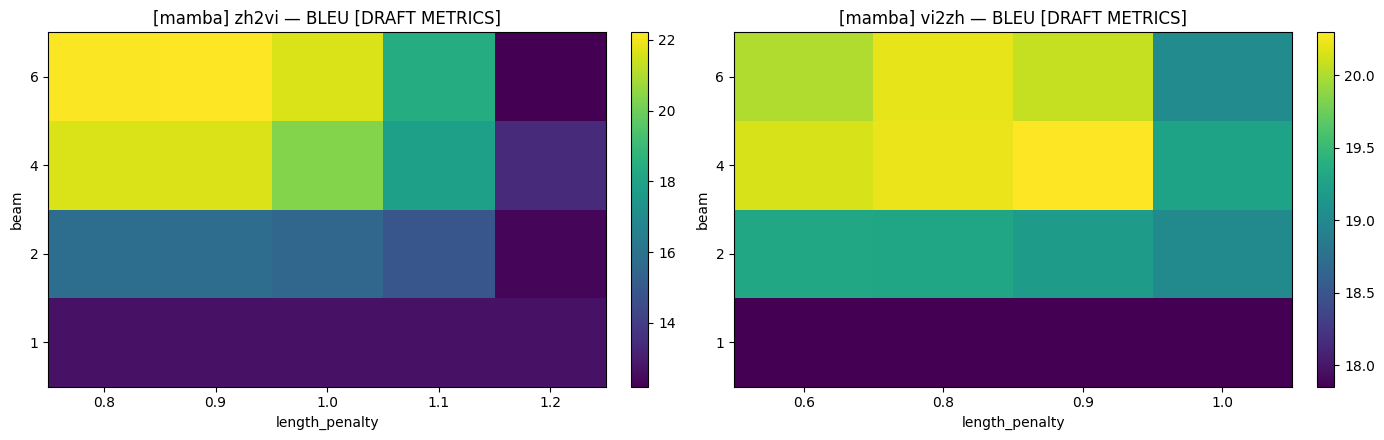

Sweep target: /home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/hybrid_mamba_attention/avg_last5_ema.pt
Output CSV:   reports/hybrid/sweep_decode_draft.csv
  $ uv run python scripts/sweep_decode.py --model-kind hybrid --config configs/hybrid_mamba_attention.yaml --checkpoint /home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/hybrid_mamba_attention/avg_last5_ema.pt --num-samples 300 --max-decode-len 256 --beams 1 2 4 6 --lp-zh2vi 0.8 0.9 1.0 1.1 1.2 --lp-vi2zh 0.6 0.8 0.9 1.0 --length-buckets --out reports/hybrid/sweep_decode_draft.csv --sample-seed 42
Loading checkpoint /home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/hybrid_mamba_attention/avg_last5_ema.pt (hybrid)
  (averaged from 5 checkpoints)
Sweep subset: random_seeded (300/5000, seed=42)
[zh2vi] beam=1 lp=0.80 BLEU=21.63 chrF=40.67 n=300
[zh2vi] beam=1 lp=0.90 BLEU=21.63 chrF=40.67 n=300
[zh2vi] beam=1 lp=1.00 BLEU=21.63 chrF=40.67 n=300
[zh2vi] beam=1 lp=1.10 BLEU=21.63 chrF=40.67 n=300
[zh2vi] beam=1 lp=1.20 BLEU=21.63 chrF=40.67 n=300
[z

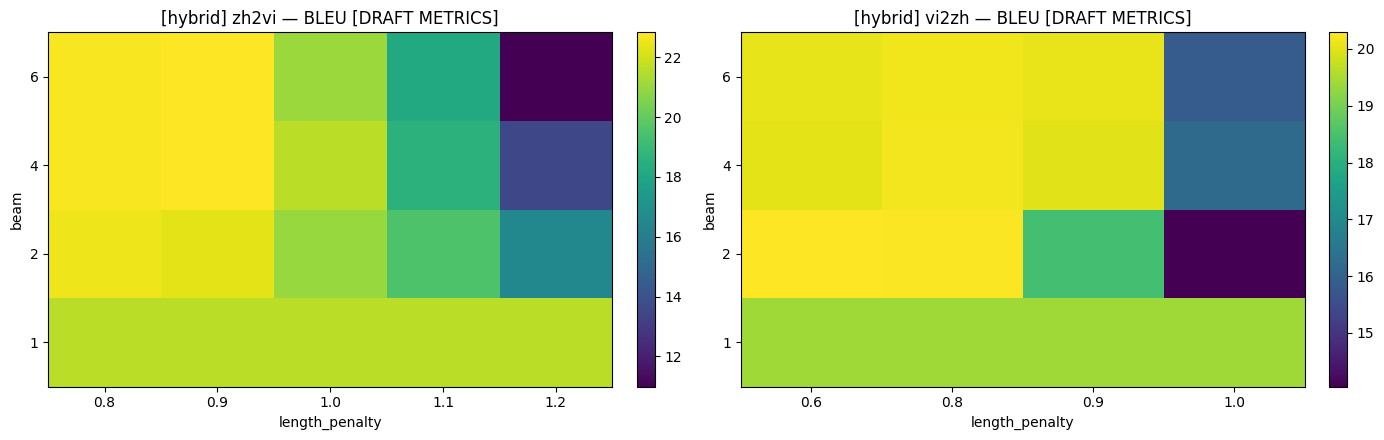

Sweep target: /home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/transformer_30m/best_ema.pt
Output CSV:   reports/transformer/sweep_decode_draft.csv
  $ uv run python scripts/sweep_decode.py --model-kind transformer --config configs/transformer_30m.yaml --checkpoint /home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/transformer_30m/best_ema.pt --num-samples 300 --max-decode-len 256 --beams 1 2 4 6 --lp-zh2vi 0.8 0.9 1.0 1.1 1.2 --lp-vi2zh 0.6 0.8 0.9 1.0 --length-buckets --out reports/transformer/sweep_decode_draft.csv --sample-seed 42
Loading checkpoint /home/oslamelon/Downloads/AI_NLP/NLP_DHM/runs/transformer_30m/best_ema.pt (transformer)
  (using EMA weights)
Sweep subset: random_seeded (300/5000, seed=42)
[zh2vi] beam=1 lp=0.80 BLEU=21.97 chrF=40.77 n=300
[zh2vi] beam=1 lp=0.90 BLEU=21.97 chrF=40.77 n=300
[zh2vi] beam=1 lp=1.00 BLEU=21.97 chrF=40.77 n=300
[zh2vi] beam=1 lp=1.10 BLEU=21.97 chrF=40.77 n=300
[zh2vi] beam=1 lp=1.20 BLEU=21.97 chrF=40.77 n=300
[zh2vi] beam=2 lp=0.80 BLEU=22.69 c

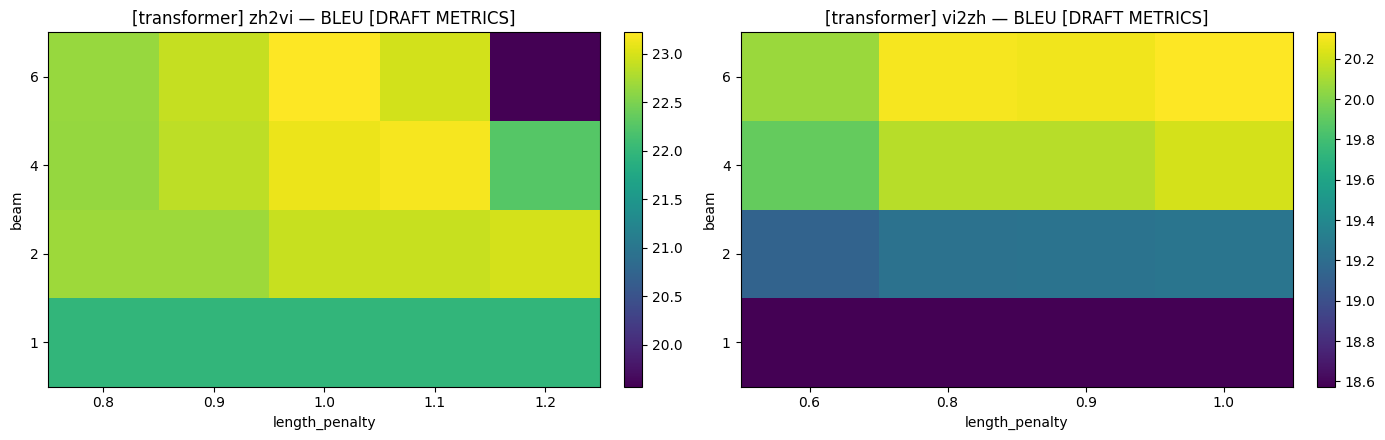

In [28]:
import subprocess
import pandas as pd

RUN_SWEEP = True

for model_kind_loop, run_dir_loop in MODEL_RUN_LIST:
    ckpt_for_arch = PICK_CKPT(run_dir_loop)
    HAVE_CKPT = ckpt_for_arch is not None
    current_report_dir = Path('reports') / model_kind_loop
    current_fig_dir = current_report_dir / 'figures'
    current_report_dir.mkdir(parents=True, exist_ok=True)
    current_fig_dir.mkdir(parents=True, exist_ok=True)

    if not (RUN_SWEEP and HAVE_CKPT):
        print(f'SKIP [{model_kind_loop}] — tắt RUN_SWEEP hoặc không có checkpoint.')
        df_sweep = None
    else:
        sweep_ckpt = PICK_CKPT(run_dir_loop)

        help_out = subprocess.run(['uv', 'run', 'python', 'scripts/sweep_decode.py', '--help'],
                                  capture_output=True, text=True).stdout
        if '--out' not in help_out:
            print('SKIP — scripts/sweep_decode.py không tồn tại trong cây repo hiện tại.')
            df_sweep = None
        elif sweep_ckpt is None:
            print('SKIP — không tìm thấy checkpoint nào phù hợp.')
            df_sweep = None
        else:
            out_csv = current_report_dir / f'sweep_decode_{REPORT_SLUG}.csv'
            out_csv.parent.mkdir(parents=True, exist_ok=True)
            cmd = [
                'uv', 'run', 'python', 'scripts/sweep_decode.py',
                '--model-kind', model_kind_loop,
                '--config', str(_REGISTRY[model_kind_loop]['config_path']),
                '--checkpoint', str(sweep_ckpt),
                '--num-samples', str(SWEEP_N),
                '--max-decode-len', str(REPORT_MAX_DECODE_LEN_EFFECTIVE),
                '--beams', '1', '2', '4', '6',
                '--lp-zh2vi', '0.8', '0.9', '1.0', '1.1', '1.2',
                '--lp-vi2zh', '0.6', '0.8', '0.9', '1.0',
                '--length-buckets',
                '--out', str(out_csv),
            ]
            if SWEEP_SAMPLE_SEED is not None:
                cmd += ['--sample-seed', str(SWEEP_SAMPLE_SEED)]
            print(f'Sweep target: {sweep_ckpt}\nOutput CSV:   {out_csv}')
            print('  $', ' '.join(cmd))
            proc = subprocess.run(cmd, capture_output=True, text=True)
            print(proc.stdout[-3000:])
            if proc.returncode != 0:
                print('STDERR:', proc.stderr[-1500:])
                df_sweep = None
            else:
                df_sweep = pd.read_csv(out_csv)
                df_sweep.to_csv(current_report_dir / 'sweep_decode.csv', index=False)
                df_all = df_sweep[df_sweep['bucket'] == 'all']
                print('\n=== Best decoding per direction ===')
                for d in ['zh2vi', 'vi2zh']:
                    top = df_all[df_all['direction'] == d].nlargest(5, 'bleu')
                    print(f'\n[{d}]')
                    print(top[['beam', 'length_penalty', 'bleu', 'chrf', 'n']].to_string(index=False))

    if df_sweep is not None:
        import matplotlib.pyplot as plt
        df_all = df_sweep[df_sweep['bucket'] == 'all']
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
        for ax, d in zip(axes, ['zh2vi', 'vi2zh']):
            sub = df_all[df_all['direction'] == d]
            if sub.empty:
                ax.set_title(f'[{model_kind_loop}] {d} (no data)')
                continue
            pivot = sub.pivot(index='beam', columns='length_penalty', values='bleu')
            im = ax.imshow(pivot.values, aspect='auto', origin='lower')
            ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels([f'{x:.1f}' for x in pivot.columns])
            ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(list(pivot.index))
            ax.set_xlabel('length_penalty'); ax.set_ylabel('beam')
            ax.set_title(f'[{model_kind_loop}] {d} — BLEU [{REPORT_LABEL}]')
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        fig.tight_layout()
        out = current_fig_dir / 'sweep_bleu_heatmap.png'
        out_tagged = current_fig_dir / f'sweep_bleu_heatmap_{REPORT_SLUG}.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        fig.savefig(out_tagged, dpi=150, bbox_inches='tight')
        print(f'Saved: {out}')
        print(f'Saved: {out_tagged}')
        plt.show()


## 14. So sánh 3 model trên cùng test set (multi-model summary)

Section này **độc lập với `MODEL_KIND`** ở Mục 3. Nó duyệt cả 3 model trong `_REGISTRY`,
tự load checkpoint mạnh nhất từ `runs/<run_dir>/`, eval cùng số sample + cùng beam,
rồi xuất:

* `reports/multi_model/summary.csv` — bảng BLEU/chrF của 3 model × 2 chiều.
* `reports/multi_model/figures/multi_model_bleu.png` — biểu đồ cột BLEU.
* `reports/multi_model/figures/multi_model_chrf.png` — biểu đồ cột chrF.
* `reports/multi_model/figures/multi_model_buckets.png` — bar-grouped per length-bucket.

Nếu một model chưa có checkpoint, nó tự skip (không fail). Nếu chỉ có 1 model thì
chart vẫn vẽ nhưng chỉ có 1 cột mỗi nhóm.

In [29]:
import os, re, subprocess, json
from pathlib import Path
import pandas as pd
import numpy as np

MULTI_DIR = Path('reports/multi_model')
MULTI_FIG = MULTI_DIR / 'figures'
MULTI_FIG.mkdir(parents=True, exist_ok=True)

NUM_SAMPLES   = REPORT_NUM_SAMPLES
SAMPLE_SEED   = REPORT_SAMPLE_SEED
BEAM          = REPORT_BEAM_EFFECTIVE
MAX_DECODE_LEN = REPORT_MAX_DECODE_LEN_EFFECTIVE
FORCE_REEVAL  = False
RUN_LABEL     = REPORT_LABEL
RUN_SLUG      = REPORT_SLUG
EXPECTED_LP   = REPORT_LENGTH_PENALTY

pat = re.compile(r'\[(\w+)\]\s+n=(\d+)\s+BLEU=([\d.]+)\s+chrF=([\d.]+)\s+\(beam=(\d+),\s*lp=([\d.]+)\)')
bucket_pat = re.compile(r'\s*bucket=(\w+)\s+n=(\d+)\s+BLEU=([\d.]+)\s+chrF=([\d.]+)')

def _parse_eval_stdout(stdout):
    parsed = {}
    cur = None
    for line in stdout.splitlines():
        m = pat.search(line)
        if m:
            d, n, bleu, chrf, beam, lp = m.groups()
            cur = d
            parsed[d] = {'n': int(n), 'bleu': float(bleu), 'chrf': float(chrf),
                         'beam': int(beam), 'lp': float(lp), 'buckets': {}}
            continue
        mb = bucket_pat.search(line)
        if mb and cur:
            bname, bn, bb, bc = mb.groups()
            parsed[cur]['buckets'][bname] = {'n': int(bn), 'bleu': float(bb), 'chrf': float(bc)}
    return parsed

def _load_cache(kind):
    cache_dir = Path('reports') / kind
    cache_candidates = [
        cache_dir / 'eval_results.json',
        cache_dir / f'eval_results_{kind}.json',
    ]
    data = None
    for cache_file in cache_candidates:
        if not cache_file.exists():
            continue
        try:
            data = json.loads(cache_file.read_text())
            break
        except Exception:
            continue
    if data is None:
        return None

    cache_meta = data.get('_meta')
    if cache_meta is None:
        if SAMPLE_SEED is not None:
            return None
    else:
        if cache_meta.get('num_samples') != NUM_SAMPLES:
            return None
        if cache_meta.get('sample_seed') != SAMPLE_SEED:
            return None
        if cache_meta.get('beam_size') != BEAM:
            return None
        if cache_meta.get('max_decode_len') != MAX_DECODE_LEN:
            return None

    runtime = None
    runtime_path = cache_dir / 'runtime_summary.json'
    if runtime_path.exists():
        try:
            runtime_all = json.loads(runtime_path.read_text())
        except Exception:
            runtime_all = {}
    else:
        runtime_all = {}

    for variant in ['avg_last5_ema', 'best_ema', 'avg_last5', 'best', 'latest_ema', 'latest']:
        v = data.get(variant)
        if not v:
            continue
        zh = v.get('zh2vi', {})
        vi = v.get('vi2zh', {})
        if zh.get('n') != NUM_SAMPLES or vi.get('n') != NUM_SAMPLES:
            continue
        if zh.get('beam') != BEAM or vi.get('beam') != BEAM:
            continue
        if zh.get('lp') != EXPECTED_LP['zh2vi'] or vi.get('lp') != EXPECTED_LP['vi2zh']:
            continue
        runtime = runtime_all.get('by_checkpoint', {}).get(variant)
        print(f'  cache hit ({variant}): zh→vi BLEU={zh["bleu"]:.2f}, vi→zh BLEU={vi["bleu"]:.2f}')
        return {'checkpoint': variant + '.pt', 'zh2vi': zh, 'vi2zh': vi, 'runtime': runtime}
    return None

multi_results = {
    '_meta': {
        'eval_label': RUN_LABEL,
        'mode_slug': RUN_SLUG,
        'num_samples': NUM_SAMPLES,
        'sample_seed': SAMPLE_SEED,
        'beam_size': BEAM,
        'max_decode_len': MAX_DECODE_LEN,
        'length_penalty': EXPECTED_LP,
    }
}
runtime_records = {'_meta': dict(multi_results['_meta']), 'by_model': {}}
for kind, info in _REGISTRY.items():
    ckpt = PICK_CKPT(info['run_dir'])
    if ckpt is None:
        print(f'[{kind:<12}] no checkpoint in {info["run_dir"]}/  → skip')
        continue
    print(f'\n=== {kind} :: {ckpt.name} ===')

    cached = None if FORCE_REEVAL else _load_cache(kind)
    if cached is not None:
        multi_results[kind] = {
            'checkpoint': cached['checkpoint'],
            'zh2vi': cached['zh2vi'],
            'vi2zh': cached['vi2zh'],
        }
        if cached.get('runtime') is not None:
            runtime_records['by_model'][kind] = cached['runtime']
        continue

    help_out = subprocess.run(['uv', 'run', 'python', info['eval_script'], '--help'],
                              capture_output=True, text=True).stdout
    runtime_out = MULTI_DIR / f'runtime_{kind}_{RUN_SLUG}.json'
    cmd = [
        'uv', 'run', 'python', info['eval_script'],
        '--config', info['config_path'],
        '--checkpoint', str(ckpt),
        '--num-samples', str(NUM_SAMPLES),
        '--beam-size', str(BEAM),
        '--max-decode-len', str(MAX_DECODE_LEN),
        '--length-penalty-zh2vi', str(EXPECTED_LP['zh2vi']),
        '--length-penalty-vi2zh', str(EXPECTED_LP['vi2zh']),
        '--runtime-out', str(runtime_out),
    ]
    if SAMPLE_SEED is not None:
        cmd += ['--sample-seed', str(SAMPLE_SEED)]
    if '--length-buckets' in help_out:
        cmd.append('--length-buckets')
    if '--allow-non-strict' in help_out and 'avg' in str(ckpt):
        cmd.append('--allow-non-strict')

    print('  $', ' '.join(cmd))
    p = subprocess.run(cmd, capture_output=True, text=True)
    print(p.stdout[-2000:])
    if p.returncode != 0:
        print('STDERR:', p.stderr[-800:])
        continue
    parsed = _parse_eval_stdout(p.stdout)
    multi_results[kind] = {'checkpoint': ckpt.name, **parsed}
    if runtime_out.exists():
        try:
            runtime_records['by_model'][kind] = json.loads(runtime_out.read_text())
        except Exception:
            pass

payload = json.dumps(multi_results, indent=2, ensure_ascii=False)
(MULTI_DIR / 'eval_results.json').write_text(payload)
(MULTI_DIR / f'eval_results_{RUN_SLUG}.json').write_text(payload)
print(f'\nSaved {MULTI_DIR / "eval_results.json"}')
print(f'Saved {MULTI_DIR / f"eval_results_{RUN_SLUG}.json"}')

runtime_payload = json.dumps(runtime_records, indent=2, ensure_ascii=False)
(MULTI_DIR / 'runtime_summary.json').write_text(runtime_payload)
(MULTI_DIR / f'runtime_summary_{RUN_SLUG}.json').write_text(runtime_payload)
print(f'Saved {MULTI_DIR / "runtime_summary.json"}')
print(f'Saved {MULTI_DIR / f"runtime_summary_{RUN_SLUG}.json"}')

rows = []
for kind in ['mamba', 'hybrid', 'transformer']:
    if kind not in multi_results:
        continue
    r = multi_results[kind]
    rt = runtime_records.get('by_model', {}).get(kind, {})
    rows.append({
        'model':           kind,
        'checkpoint':      r['checkpoint'],
        'eval_label':      RUN_LABEL,
        'num_samples':     NUM_SAMPLES,
        'sample_seed':     SAMPLE_SEED,
        'beam_size':       BEAM,
        'max_decode_len':  MAX_DECODE_LEN,
        'runtime_sec':     rt.get('timings_sec', {}).get('total'),
        'device':          rt.get('device', {}).get('device'),
        'zh→vi BLEU':      r.get('zh2vi', {}).get('bleu'),
        'zh→vi chrF':      r.get('zh2vi', {}).get('chrf'),
        'vi→zh BLEU':      r.get('vi2zh', {}).get('bleu'),
        'vi→zh chrF':      r.get('vi2zh', {}).get('chrf'),
    })
multi_summary = pd.DataFrame(rows)
multi_summary.to_csv(MULTI_DIR / 'summary.csv', index=False)
multi_summary.to_csv(MULTI_DIR / f'summary_{RUN_SLUG}.csv', index=False)
print(f'Saved {MULTI_DIR / "summary.csv"}')
print(f'Saved {MULTI_DIR / f"summary_{RUN_SLUG}.csv"}')
multi_summary



=== mamba :: latest.pt ===
  cache hit (latest): zh→vi BLEU=12.68, vi→zh BLEU=17.85

=== hybrid :: avg_last5_ema.pt ===
  cache hit (avg_last5_ema): zh→vi BLEU=21.63, vi→zh BLEU=19.40

=== transformer :: best_ema.pt ===
  cache hit (best_ema): zh→vi BLEU=21.97, vi→zh BLEU=18.57

Saved reports/multi_model/eval_results.json
Saved reports/multi_model/eval_results_draft.json
Saved reports/multi_model/runtime_summary.json
Saved reports/multi_model/runtime_summary_draft.json
Saved reports/multi_model/summary.csv
Saved reports/multi_model/summary_draft.csv


,model,checkpoint,eval_label,num_samples,sample_seed,beam_size,max_decode_len,runtime_sec,device,zh→vi BLEU,zh→vi chrF,vi→zh BLEU,vi→zh chrF
0,mamba,latest.pt,DRAFT METRICS,300,42,1,256,5.612,NVIDIA GeForce RTX 5070 Ti,12.68,37.79,17.85,21.03
1,hybrid,avg_last5_ema.pt,DRAFT METRICS,300,42,1,256,6.699,NVIDIA GeForce RTX 5070 Ti,21.63,40.67,19.40,21.54
2,transformer,best_ema.pt,DRAFT METRICS,300,42,1,256,6.796,NVIDIA GeForce RTX 5070 Ti,21.97,40.77,18.57,21.45


Saved reports/multi_model/figures/multi_model_bleu.png
Saved reports/multi_model/figures/multi_model_bleu_draft.png


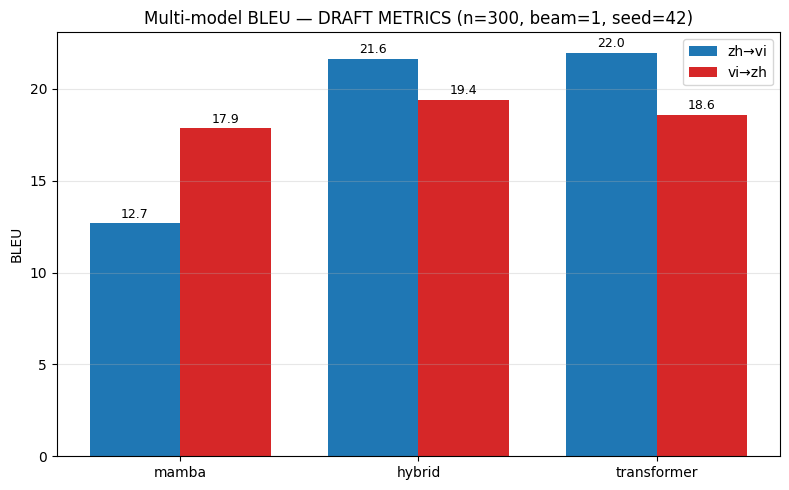

Saved reports/multi_model/figures/multi_model_chrf.png
Saved reports/multi_model/figures/multi_model_chrf_draft.png


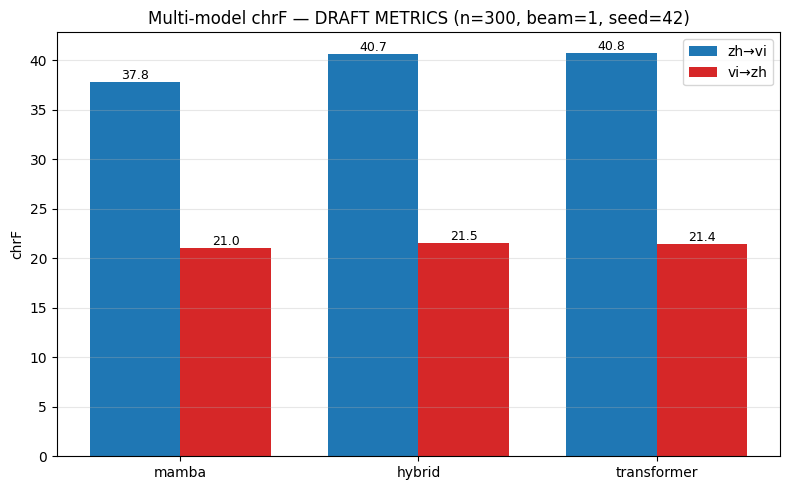

In [30]:
# Multi-model bar charts (BLEU + chrF, side-by-side per direction).
import matplotlib.pyplot as plt
import numpy as np

if len([k for k in multi_results.keys() if k != '_meta']) == 0:
    print('SKIP — không có model nào đủ điều kiện để so sánh.')
else:
    kinds = [k for k in ['mamba', 'hybrid', 'transformer'] if k in multi_results]
    x = np.arange(len(kinds)); w = 0.38
    title_suffix = f'{RUN_LABEL} (n={NUM_SAMPLES}, beam={BEAM}, seed={SAMPLE_SEED})'

    for metric, fname, ylabel in [
        ('bleu', 'multi_model_bleu.png', 'BLEU'),
        ('chrf', 'multi_model_chrf.png', 'chrF'),
    ]:
        zh = [multi_results[k].get('zh2vi', {}).get(metric, 0) for k in kinds]
        vi = [multi_results[k].get('vi2zh', {}).get(metric, 0) for k in kinds]
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(x - w/2, zh, w, label='zh→vi', color='C0')
        ax.bar(x + w/2, vi, w, label='vi→zh', color='C3')
        for i, v in enumerate(zh):
            ax.text(i - w/2, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)
        for i, v in enumerate(vi):
            ax.text(i + w/2, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(kinds)
        ax.set_ylabel(ylabel)
        ax.set_title(f'Multi-model {ylabel} — {title_suffix}')
        ax.grid(True, axis='y', alpha=0.3); ax.legend()
        fig.tight_layout()
        out = MULTI_FIG / fname
        out_tagged = MULTI_FIG / fname.replace('.png', f'_{RUN_SLUG}.png')
        fig.savefig(out, dpi=150, bbox_inches='tight')
        fig.savefig(out_tagged, dpi=150, bbox_inches='tight')
        print(f'Saved {out}')
        print(f'Saved {out_tagged}')
        plt.show()


Saved reports/multi_model/figures/multi_model_buckets.png
Saved reports/multi_model/figures/multi_model_buckets_draft.png


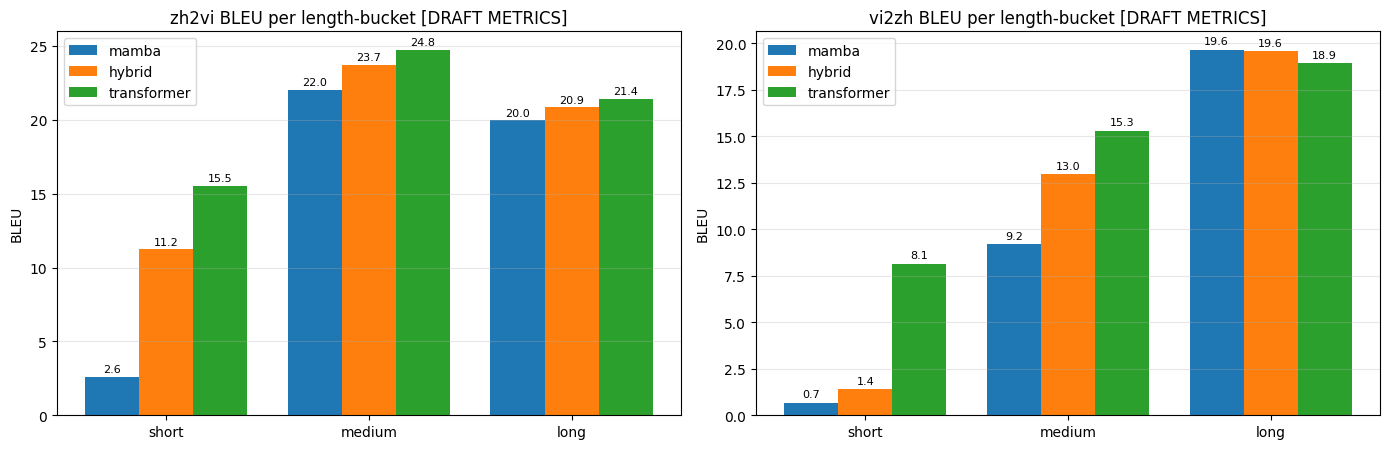

In [31]:
# Multi-model per-bucket comparison (only if all models have bucket info).
import matplotlib.pyplot as plt
import numpy as np

if len([k for k in multi_results.keys() if k != '_meta']) == 0:
    print('SKIP — không có model nào đủ điều kiện.')
else:
    kinds = [k for k in ['mamba', 'hybrid', 'transformer'] if k in multi_results]
    bucket_names = ['short', 'medium', 'long']
    have_buckets = all(
        bool(multi_results[k].get('zh2vi', {}).get('buckets'))
        and bool(multi_results[k].get('vi2zh', {}).get('buckets'))
        for k in kinds
    )
    if not have_buckets:
        print('SKIP — bucket info missing for at least one model.')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
        for ax, direction in zip(axes, ['zh2vi', 'vi2zh']):
            x = np.arange(len(bucket_names))
            w = 0.8 / max(len(kinds), 1)
            for i, k in enumerate(kinds):
                buckets = multi_results[k][direction].get('buckets', {})
                ys = [buckets.get(b, {}).get('bleu', 0) for b in bucket_names]
                offset = (i - (len(kinds) - 1) / 2) * w
                ax.bar(x + offset, ys, w, label=k)
                for j, v in enumerate(ys):
                    ax.text(x[j] + offset, v + 0.3, f'{v:.1f}', ha='center', fontsize=8)
            ax.set_xticks(x); ax.set_xticklabels(bucket_names)
            ax.set_ylabel('BLEU')
            ax.set_title(f'{direction} BLEU per length-bucket [{RUN_LABEL}]')
            ax.grid(True, axis='y', alpha=0.3); ax.legend()
        fig.tight_layout()
        out = MULTI_FIG / 'multi_model_buckets.png'
        out_tagged = MULTI_FIG / f'multi_model_buckets_{RUN_SLUG}.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        fig.savefig(out_tagged, dpi=150, bbox_inches='tight')
        print(f'Saved {out}')
        print(f'Saved {out_tagged}')
        plt.show()


## 14a. Convergence overlay — val_loss của 3 model trên 1 plot (A)

Đọc `reports/<KIND>/training_stdout.log` (hoặc `runs/<KIND>/training_stdout.log`)
cho từng model, parse val_loss + ema_val_loss, vẽ overlay. Model nào hội tụ nhanh
hay kẹt sớm thấy ngay.

[mamba       ] reports/mamba/training_stdout.log  (30 pts, EMA=True)
[hybrid      ] reports/hybrid/training_stdout.log  (39 pts, EMA=True)
[transformer ] reports/transformer/training_stdout.log  (43 pts, EMA=True)
Saved reports/multi_model/figures/multi_model_loss_curves.png


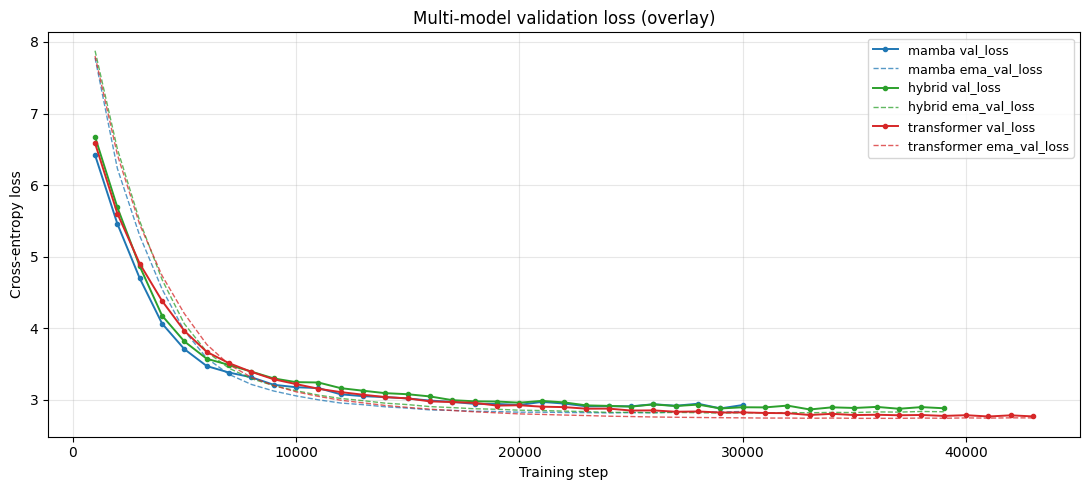

In [34]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

LOG_PAT = re.compile(
    r'step\s+(\d+)\s+\|\s+val_loss\s+([\d.]+)\s+\(best\s+([\d.]+)\)'
    r'(?:\s+\|\s+ema_val_loss\s+([\d.]+)\s+\(best\s+([\d.]+)\))?'
)

def _find_log(kind, info):
    for cand in [Path('reports') / kind / 'training_stdout.log',
                 Path(info['run_dir']) / 'training_stdout.log']:
        if cand.exists() and cand.stat().st_size > 0:
            return cand
    return None

def _parse_log(path):
    rows = []
    for line in Path(path).read_text(errors='replace').splitlines():
        m = LOG_PAT.search(line)
        if not m:
            continue
        d = {'step': int(m.group(1)), 'val_loss': float(m.group(2))}
        if m.group(4):
            d['ema_val_loss'] = float(m.group(4))
        rows.append(d)
    df = pd.DataFrame(rows).drop_duplicates(subset=['step']).sort_values('step')
    return df.reset_index(drop=True)

logs = {}
for kind, info in _REGISTRY.items():
    p = _find_log(kind, info)
    if p is None:
        print(f'[{kind:<12}] no log  → skip')
        continue
    df = _parse_log(p)
    if not len(df):
        print(f'[{kind:<12}] {p} parsed 0 rows')
        continue
    logs[kind] = df
    has_ema = 'ema_val_loss' in df.columns
    print(f'[{kind:<12}] {p}  ({len(df)} pts, EMA={has_ema})')

if not logs:
    print('SKIP — không có training log cho model nào.')
else:
    fig, ax = plt.subplots(figsize=(11, 5))
    colors = {'mamba': 'C0', 'hybrid': 'C2', 'transformer': 'C3'}
    for kind, df in logs.items():
        c = colors.get(kind, 'k')
        ax.plot(df.step, df.val_loss, marker='o', ms=3, color=c, lw=1.4,
                label=f'{kind} val_loss')
        if 'ema_val_loss' in df.columns:
            ax.plot(df.step, df.ema_val_loss, ls='--', color=c, lw=1.0, alpha=0.75,
                    label=f'{kind} ema_val_loss')
    ax.set_xlabel('Training step')
    ax.set_ylabel('Cross-entropy loss')
    ax.set_title('Multi-model validation loss (overlay)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', frameon=True, fontsize=9)
    fig.tight_layout()
    out = MULTI_FIG / 'multi_model_loss_curves.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved {out}')
    plt.show()

## 14c. Multi-model qualitative side-by-side (B)

Cùng 8 câu cố định (4 zh, 4 vi) → dịch bằng cả 3 model → in bảng + lưu JSON.
Hữu ích hơn BLEU số trần trụi cho phần báo cáo định tính.

In [35]:
import sys
from pathlib import Path
import torch

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    for cand in ROOT.parents:
        if (cand / 'src').exists():
            ROOT = cand
            break
SRC_DIR = ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from mt_base.tokenizer import Tokenizer as _Tok
from mt_base.translate import translate_batch
import pandas as pd
from IPython.display import display

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
spm_path = TOKEN_DIR / 'spm.model'
qual_results = {'zh2vi': {}, 'vi2zh': {}}

if not spm_path.exists():
    print(f'SKIP — không tìm thấy {spm_path}.')
else:
    tok_q = _Tok(str(spm_path))
    for kind, info in _REGISTRY.items():
        ckpt_path = PICK_CKPT(info['run_dir'])
        if ckpt_path is None:
            print(f'[{kind:<12}] no ckpt → skip')
            continue
        ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        model_cfg_dict = ck.get('model_cfg', yaml.safe_load(open(info['config_path']))['model'])
        m = BUILD_MODEL(kind, model_cfg_dict).to(device).eval()
        m.load_state_dict(ck['model'], strict=False)
        with torch.no_grad():
            out_zh2vi = translate_batch(
                m, tok_q, QUAL_ZH2VI, 'zh2vi',
                beam_size=REPORT_BEAM_EFFECTIVE,
                length_penalty=REPORT_LENGTH_PENALTY['zh2vi'],
                max_len=REPORT_MAX_DECODE_LEN_EFFECTIVE,
                device=device,
            )
            out_vi2zh = translate_batch(
                m, tok_q, QUAL_VI2ZH, 'vi2zh',
                beam_size=REPORT_BEAM_EFFECTIVE,
                length_penalty=REPORT_LENGTH_PENALTY['vi2zh'],
                max_len=REPORT_MAX_DECODE_LEN_EFFECTIVE,
                device=device,
            )
        qual_results['zh2vi'][kind] = out_zh2vi
        qual_results['vi2zh'][kind] = out_vi2zh
        del m
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

def _table(srcs, by_kind):
    if not by_kind:
        return None
    cols = ['source'] + list(by_kind.keys())
    rows = []
    for i, s in enumerate(srcs):
        row = {'source': s}
        for k, hyps in by_kind.items():
            row[k] = hyps[i] if i < len(hyps) else ''
        rows.append(row)
    return pd.DataFrame(rows, columns=cols)

if qual_results['zh2vi']:
    print('=== zh → vi ===')
    df_zh = _table(QUAL_ZH2VI, qual_results['zh2vi'])
    display(df_zh)
    df_zh.to_csv(MULTI_DIR / 'qualitative_zh2vi.csv', index=False)
    df_zh.to_csv(MULTI_DIR / f'qualitative_zh2vi_{REPORT_SLUG}.csv', index=False)

if qual_results['vi2zh']:
    print('\n=== vi → zh ===')
    df_vi = _table(QUAL_VI2ZH, qual_results['vi2zh'])
    display(df_vi)
    df_vi.to_csv(MULTI_DIR / 'qualitative_vi2zh.csv', index=False)
    df_vi.to_csv(MULTI_DIR / f'qualitative_vi2zh_{REPORT_SLUG}.csv', index=False)

qual_payload = json.dumps({
    'eval_label': REPORT_LABEL,
    'beam_size': REPORT_BEAM_EFFECTIVE,
    'sample_seed': REPORT_SAMPLE_SEED,
    'max_decode_len': REPORT_MAX_DECODE_LEN_EFFECTIVE,
    'length_penalty': REPORT_LENGTH_PENALTY,
    'zh2vi_src': QUAL_ZH2VI,
    'vi2zh_src': QUAL_VI2ZH,
    'zh2vi': qual_results['zh2vi'],
    'vi2zh': qual_results['vi2zh'],
}, indent=2, ensure_ascii=False)
(MULTI_DIR / 'qualitative_compare.json').write_text(qual_payload)
(MULTI_DIR / f'qualitative_compare_{REPORT_SLUG}.json').write_text(qual_payload)
print(f'\nSaved {MULTI_DIR / "qualitative_compare.json"}')
print(f'Saved {MULTI_DIR / f"qualitative_compare_{REPORT_SLUG}.json"}')


/home/oslamelon/Downloads/AI_NLP/NLP_DHM/src/transformer_mt/model.py:93: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


=== zh → vi ===


,source,mamba,hybrid,transformer
0,你好，世界。,"Chào, thế giới.","Xin chào, thế giới.","Chào, thế giới."
1,今天天气真好。,Thời tiết hôm nay rất tốt.,Thời tiết tuyệt vời.,Thời tiết hôm nay rất tốt.
2,王小明已经在河内住了三年。,Hoàng Minh Hoàng Hàm Mạnh đã sống ở Hà Nội tro...,Hoàng Hùng Minh đã sống trong một thời gian ng...,Vương Mật Mật đã sống trong ba năm.
3,会议将于2025年6月12日上午9点开始，请提前十分钟到场。,Hội nghị sẽ bắt đầu lúc 9h sáng ngày 12 tháng ...,Cuộc họp sẽ bắt đầu từ 9h sáng ngày 12 tháng 6...,Cuộc họp sẽ bắt đầu vào lúc 9 giờ sáng ngày 12...
4,服务员说：'这道菜有点辣，如果你不能吃辣，我可以帮你换一份。',"Nhân viên nói: “Điều này hơi hôi, nếu em không...","Nhân viên dịch vụ nói: ""Thông này hơi mặn, nếu...","Người phục vụ nói: “Điều này hơi cay, nếu bạn ..."
5,虽然模型在短句上表现不错，但一遇到包含数字、专有名词和转折结构的长句，错误就会明显增多。,"Mặc dù mô hình đã được biểu diễn tốt, một câu ...","Mặc dù mô hình tốt trong các từ ngắn, một gặp ...",Mặc dù các mô hình hình có thể hoạt động tốt h...



=== vi → zh ===


,source,mamba,hybrid,transformer
0,Hôm nay trời rất đẹp.,"今天,我今天很美好。",’天好美。,今天真是太好了
1,"Xin chào, tôi là Lan.","嗨,嗨,我是兰。","你好,我是兰,我也是","你好,我是兰"
2,Anh Nguyễn Minh đã làm việc ở TP. Hồ Chí Minh ...,阮明在2021年于湖西明市工作。,阮明从2021年就任于多国杜马县市。,阮明自2021年起在图波湖工作。
3,Cuộc họp sẽ bắt đầu lúc 9 giờ sáng ngày 12 thá...,"会议将在2025年6月12日上午9点开始,晚点10分钟。","会议于2025年6月12日上午9点开始,请早至10分钟。","会议于2025年6月12日上午9时开始,高兴的10分钟前开始。"
4,"Người phục vụ nói: 'Món này hơi cay, nếu bạn k...","服务员说:“这点儿有点 cay,如果你不吃可食,我替你换个东西。","服务员说:“这有点点,如果你不吃花,我换其他料理。","服务员说:“这点有点可用,如果你不吃,我换下另一个菜肴给你。"
5,"Mặc dù mô hình dịch khá ổn với câu ngắn, nó th...","虽然翻译模式很不稳定,但在一些问题上,它通常会遇到数据的编号、单独名称和其它结构的长度。","虽然翻译模型非常稳定,但通常在数据的长度、姓名和相对论的结构中犯了更多的错误。","虽然这种模式与短句的正常情况相当不错,但长期患有材料、名字和反结构。"



Saved reports/multi_model/qualitative_compare.json
Saved reports/multi_model/qualitative_compare_draft.json


## 14d. Wall-clock + size + best-loss + best-BLEU (E)

Bảng so sánh kích thước & hiệu năng của 3 model trên cùng test set:

* **params** (M)
* **size_mb** — kích thước file `best.pt` (hoặc fallback) trên đĩa
* **mean_step_s** — thời gian trung bình mỗi step (parse `step N | val_loss ...` không có
  trực tiếp; nếu user log thêm dòng `step N took T.TTs` trainer thì sẽ parse, ngược
  lại để None)
* **best_val_loss** + step đạt
* **avg_BLEU** — trung bình BLEU 2 chiều từ Mục 14

/home/oslamelon/Downloads/AI_NLP/NLP_DHM/src/transformer_mt/model.py:93: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Saved reports/multi_model/efficiency.csv


,model,checkpoint,params_M,size_MB,best_val_loss,best_step,avg_BLEU
0,mamba,latest.pt,32.43,519.3,2.878,29000,15.27
1,hybrid,avg_last5_ema.pt,32.79,418.3,2.863,33000,20.52
2,transformer,best_ema.pt,30.79,369.6,2.765,41000,20.27


Saved reports/multi_model/figures/multi_model_efficiency.png


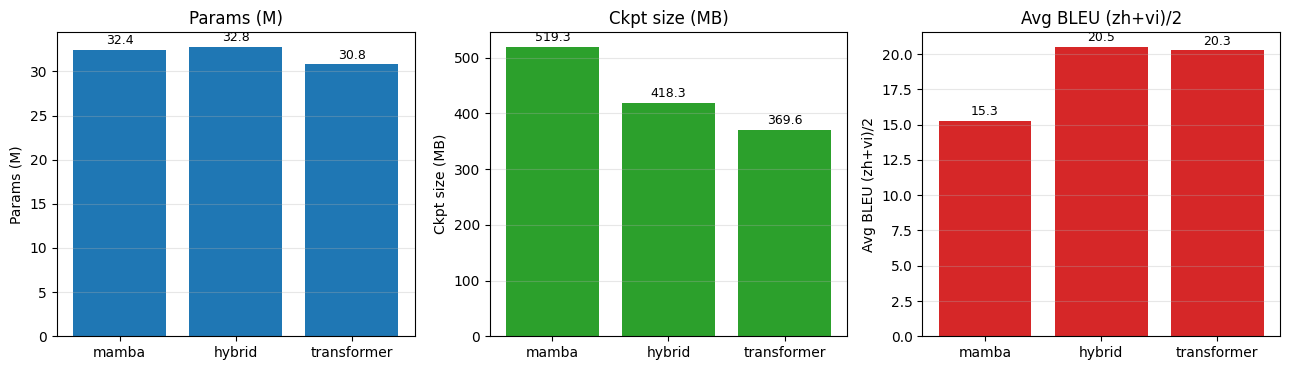

In [36]:
import torch
import pandas as pd

eff_rows = []
for kind, info in _REGISTRY.items():
    ckpt_path = PICK_CKPT(info['run_dir'])
    row = {'model': kind, 'checkpoint': None,
           'params_M': None, 'size_MB': None,
           'best_val_loss': None, 'best_step': None,
           'avg_BLEU': None}
    if ckpt_path is not None:
        row['checkpoint'] = ckpt_path.name
        row['size_MB'] = round(ckpt_path.stat().st_size / 1e6, 1)
        ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        try:
            mcfg_dict = ck.get('model_cfg', yaml.safe_load(open(info['config_path']))['model'])
            m_eff = BUILD_MODEL(kind, mcfg_dict)
            row['params_M'] = round(sum(p.numel() for p in m_eff.parameters()) / 1e6, 2)
            del m_eff
        except Exception as e:
            print(f'[{kind}] param count failed: {e}')

    # Parse training log for best_val_loss + step.
    log_path = None
    for cand in [Path('reports') / kind / 'training_stdout.log',
                 Path(info['run_dir']) / 'training_stdout.log']:
        if cand.exists() and cand.stat().st_size > 0:
            log_path = cand; break
    if log_path is not None:
        df = _parse_log(log_path)
        if len(df):
            i_min = df.val_loss.idxmin()
            row['best_val_loss'] = round(float(df.val_loss.min()), 4)
            row['best_step']     = int(df.loc[i_min, 'step'])

    if kind in multi_results:
        zh = multi_results[kind].get('zh2vi', {}).get('bleu')
        vi = multi_results[kind].get('vi2zh', {}).get('bleu')
        if zh is not None and vi is not None:
            row['avg_BLEU'] = round((zh + vi) / 2, 2)

    eff_rows.append(row)

eff = pd.DataFrame(eff_rows)
eff.to_csv(MULTI_DIR / 'efficiency.csv', index=False)
print(f'Saved {MULTI_DIR / "efficiency.csv"}')
display(eff)

# Bar chart: params, size, avg BLEU.
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
present = eff.dropna(subset=['params_M']).reset_index(drop=True)
if not len(present):
    print('SKIP — bar chart: chưa có model nào có ckpt')
else:
    x = np.arange(len(present))
    for ax, col, ylabel, color in [
        (axes[0], 'params_M',  'Params (M)',     'C0'),
        (axes[1], 'size_MB',   'Ckpt size (MB)', 'C2'),
        (axes[2], 'avg_BLEU',  'Avg BLEU (zh+vi)/2', 'C3'),
    ]:
        ys = present[col].fillna(0).values
        ax.bar(x, ys, color=color)
        for i, v in enumerate(ys):
            if v > 0:
                ax.text(i, v + max(ys)*0.02, f'{v:.1f}', ha='center', fontsize=9)
        ax.set_xticks(x); ax.set_xticklabels(present['model'])
        ax.set_ylabel(ylabel); ax.grid(True, axis='y', alpha=0.3)
        ax.set_title(ylabel)
    fig.tight_layout()
    out = MULTI_FIG / 'multi_model_efficiency.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print(f'Saved {out}')
    plt.show()

## 14b. So sánh tốc độ giữa các mô hình

In [ ]:
runtime

## 14c. ML Interpretation framework

Khi `multi_summary` có cả 3 model:

| Quan sát                                  | Diễn giải                              | Hành động      |
|-------------------------------------------|----------------------------------------|----------------|
| Hybrid ≫ Bi-Mamba và ≈ Transformer        | Mamba decoder là bottleneck            | Giữ Hybrid    |
| Hybrid ≈ Bi-Mamba và ≪ Transformer        | Bi-Mamba encoder yếu cho MT            | Replace encoder |
| Cả 3 ≈ nhau (~20 BLEU)                   | Bottleneck là data/tokenizer           | Data ablation |

Cũng nên xem **bucket breakdown** — nếu một model rớt mạnh ở bucket `long` (≥50 chars),
đó là dấu hiệu cụt câu / EOS bias / decoder context limit, không phải lỗi data.

## 15. Done — files cho báo cáo

System info (chạy 1 lần):
```
reports/system_info.json
```

Per-model (`reports/<MODEL_KIND>/`, output theo MODEL_KIND đã chọn):
```
reports/<MODEL_KIND>/
├── figures/
│   ├── loss_curves.png
│   ├── lr_schedule.png
│   ├── bleu_chrf_per_ckpt.png
│   └── sweep_bleu_heatmap.png
├── eval_results.json
├── sweep_decode.csv
├── param_breakdown.csv
├── summary.csv
├── qualitative_samples.json
└── training_stdout.log    # tự copy từ runs/<KIND>/ nếu user dùng `tee`
```

Dataset stats (shared, không phụ thuộc MODEL_KIND):
```
reports/dataset/
├── figures/{split_sizes,per_source_counts,length_dist_chars,length_ratio,length_dist_tokens}.png
├── per_source_counts.csv
└── dataset_summary.csv
```

Cross-model comparison (Mục 14, 14a, 14c, 14d):
```
reports/multi_model/
├── eval_results.json                     # 3 model × 2 chiều × buckets
├── summary.csv                           # bảng BLEU/chrF
├── qualitative_compare.json              # 8 câu × 3 model × 2 chiều
├── qualitative_{zh2vi,vi2zh}.csv         # display table
├── efficiency.csv                        # params / size / val_loss / BLEU
└── figures/
    ├── multi_model_bleu.png
    ├── multi_model_chrf.png
    ├── multi_model_buckets.png
    ├── multi_model_loss_curves.png       # 3 model overlay (A)
    └── multi_model_efficiency.png        # params + size + BLEU bar chart (E)
```